# Spectral analysis (FFT) of detrended residuals

**Input:** CSV `<solution>_<product>_<station>_detr.csv` with `year`, `res_dE`, `res_dN`, `res_dU`.  
**What it does:** Z-scores residuals, runs one-sided rFFT, finds dominant peaks, and (optionally) removes them.  
**Output (data):** `periodogram_results[comp]` (freq, period, amplitude_z, amplitude_mm) and `df_aper` with `aper_dE/N/U`.  
**Output (figures):** `{IMAGE_NAME}_amplitude_mm.pdf` and `{IMAGE_NAME}_sum_periodic_components_with_aper.pdf`.  
**How it works:** rFFT → amplitudes (z & mm) → peak picking (prominence + period range) → reconstruct periodic part → aperiodic = residual − periodic.  
**Assumptions:** residuals already detrended/de-jumped; sampling ~uniform (small gaps OK; larger gaps → prefer Lomb–Scargle).

### Imports

**Standard library**
- `pathlib.Path` – filesystem paths (object-oriented)
- `typing.Optional`, `typing.Tuple` – type hints for optional arguments and return tuples
- `sys` – system-specific parameters and runtime environment

**Third-party**
- [`numpy`](https://numpy.org) – numerical arrays and vectorized operations  
- [`pandas`](https://pandas.pydata.org) – tabular data manipulation and CSV I/O  
- [`matplotlib.pyplot`](https://matplotlib.org) – plotting and figure creation  
- [`scipy.signal`](https://scipy.org) – signal processing utilities (FFT peak detection)

In [1]:
# --- Standard library ---
from pathlib import Path                     # filesystem paths (object-oriented)
from typing import Optional, Tuple           # type hints for return types
import sys                                   # system-specific parameters and functions

# --- Third-party packages ---
try:
    import numpy as np                       # numerical arrays and vectorized ops
except ImportError as e:
    raise RuntimeError("Missing dependency: 'numpy'. Install it with:\n  pip install numpy") from e

try:
    import pandas as pd                      # tabular dataframes
except ImportError as e:
    raise RuntimeError("Missing dependency: 'pandas'. Install it with:\n  pip install pandas") from e

try:
    import matplotlib.pyplot as plt          # plotting
except ImportError as e:
    raise RuntimeError("Missing dependency: 'matplotlib'. Install it with:\n  pip install matplotlib") from e

try:
    from scipy.signal import find_peaks      # peak picking in amplitude spectra
except ImportError as e:
    raise RuntimeError("Missing dependency: 'scipy'. Install it with:\n  pip install scipy") from e

# --- doris package ---
_src = Path("../..").resolve() / "src"
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

try:
    from doris.analysis.spectral import (
        compute_periodogram as _doris_pg,
        estimate_periodogram_threshold,
        find_significant_peaks,
    )
except ImportError as e:
    raise RuntimeError(
        "Missing doris modules. Make sure the project src path is on PYTHONPATH "
        "or run the notebook from: notebooks/stations."
    ) from e

### Paths and constants

In [2]:
# --- Dataset selection ---
PRODUCT       = "stcd"
SOLUTION      = "gop25wd04"
STATION       = "LICB"
TREND_VARIANT = "weighted_multiseg"  # options: weighted_1seg, weighted_2seg, weighted_multiseg

# --- Project root (two levels up from notebooks/stations/) ---
PROJECT_ROOT = Path("../..").resolve()

# --- Data paths ---
DATA_DIR   = PROJECT_ROOT / "data" / PRODUCT.lower() / SOLUTION.lower()
EXPORT_DIR = DATA_DIR / "exports" / STATION.lower()
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# --- Image output ---
IMAGES_DIR = PROJECT_ROOT / "LaTeX" / "images" / "Stations" / STATION
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

# --- File names ---
BASE_NAME  = f"{SOLUTION.lower()}_{PRODUCT.lower()}_{STATION.lower()}"
IMAGE_NAME = BASE_NAME
DETR_CSV   = EXPORT_DIR / f"{BASE_NAME}_detr_{TREND_VARIANT}.csv"
APER_CSV   = EXPORT_DIR / f"{BASE_NAME}_aper_{TREND_VARIANT}.csv"

# --- Components ---
components = ["dE", "dN", "dU"]

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DETR_CSV:    ", DETR_CSV)
print("Exists:      ", DETR_CSV.exists())
print("IMAGES_DIR:  ", IMAGES_DIR)

PROJECT_ROOT: C:\Users\michal\Desktop\MasterThesis-DorisAnalysis
DETR_CSV:     C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\data\stcd\gop25wd04\exports\licb\gop25wd04_stcd_licb_detr_weighted_multiseg.csv
Exists:       True
IMAGES_DIR:   C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\images\Stations\LICB


### load STCD data
Finds the first numeric row in a plaintext STCD table and reads the rest as whitespace-delimited data.

In [3]:
# --- Load detrended CSV ---
if not DETR_CSV.exists():
    # Collect candidate files to help the user diagnose typos / wrong paths
    candidates_station = sorted(EXPORT_DIR.glob(f"*_{STATION.strip().lower()}_detr.csv"))
    candidates_all     = sorted(EXPORT_DIR.glob("*_detr.csv"))

    # Build a human-readable hint message
    lines = []
    if candidates_station:
        lines.append("Matching this station:")
        lines += [f"  - {p.name}" for p in candidates_station]
    elif candidates_all:
        lines.append("Available detrended exports in folder:")
        lines += [f"  - {p.name}" for p in candidates_all]
    else:
        lines.append("(no *_detr.csv files found in exports/)")

    hint = "\n".join(lines)
    raise FileNotFoundError(f"File not found:\n  {DETR_CSV}\n\n{hint}")

# Read CSV once the path is confirmed to exist
df_detr = pd.read_csv(DETR_CSV)
print(f"✔️ Loaded {len(df_detr)} rows from {DETR_CSV}")

# Quick display
df_detr.head()
# Create time-from-start column required by doris compute_periodogram
df_detr["t_year"] = df_detr["year"] - df_detr["year"].iloc[0]

✔️ Loaded 543 rows from C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\data\stcd\gop25wd04\exports\licb\gop25wd04_stcd_licb_detr_weighted_multiseg.csv


### Summarize displacement data  
Shows start/end year and basic stats (min, max, mean, std) for dE, dN, dU.  
Use: `summary_table = summarize_displacement(df_detr)` -> quick overview of motion range.

In [4]:
def summarize_displacement(df):
    """
    Summarize basic statistics for displacement data (works for both test and real formats).
    Assumes columns: 'year', 'dE', 'dN', 'dU'.
    Returns:
        - Start and end year of the series.
        - Min, max, mean, std for dE, dN, dU.
    """
    # Extract basic time info
    start_year = df['year'].min()
    end_year = df['year'].max()

    # Calculate stats for each component
    stats = {}
    for comp in components:
        stats[comp] = {
            'min': df[comp].min(),
            'max': df[comp].max(),
            'mean': df[comp].mean(),
            'std': df[comp].std()
        }

    # Convert to DataFrame
    stats_df = pd.DataFrame(stats).T
    stats_df.index.name = 'Component'

    print(f"Start year: {start_year:.3f}")
    print(f"End year:   {end_year:.3f}")
    print(f"Time span:  {end_year - start_year:.3f} years\n")

    return stats_df

# Example usage (works for both df_filt or a real DORIS DataFrame)
summary_table = summarize_displacement(df_detr)
summary_table

Start year: 2015.018
End year:   2025.481
Time span:  10.463 years



,min,max,mean,std
Component,,,,
dE,305.3,629.3,452.879374,67.708511
dN,270.6,501.2,384.076427,60.441651
dU,-58.6,25.8,-8.716759,13.123451


### Plot detrended residuals
Scatter residuals per axis (`res_dN`, `res_dE`, `res_dU`) vs. `year`.

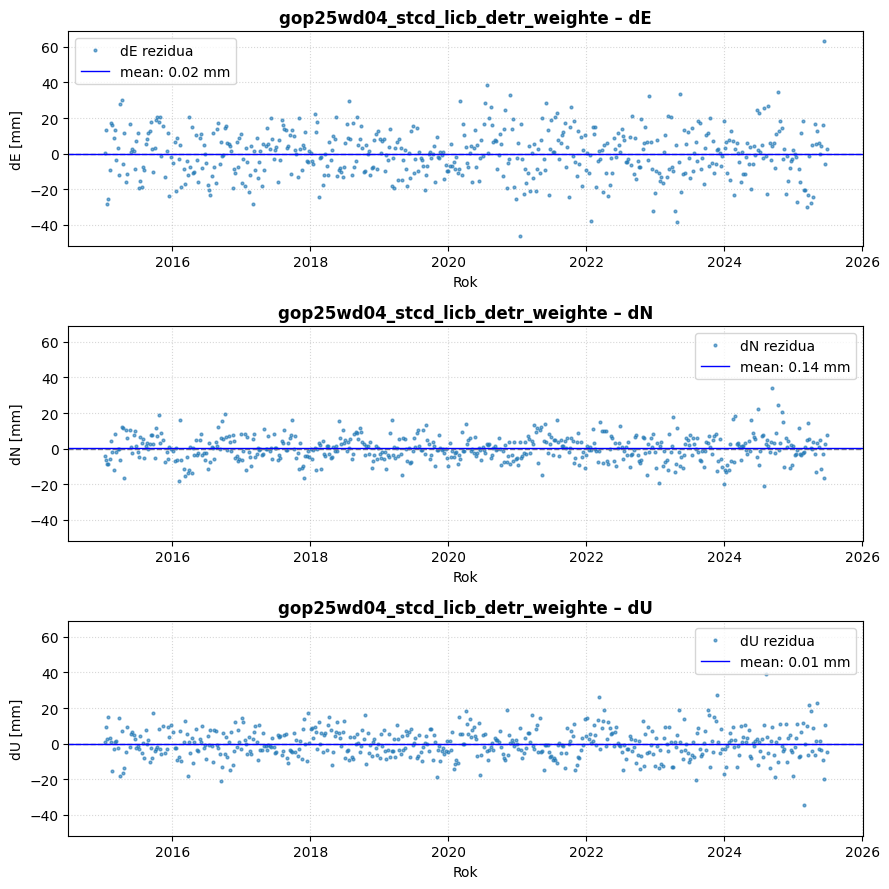

In [5]:
# Plot detrended residuals
fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=False, sharey=True)

for ax, comp in zip(axes, components):
    y_res = df_detr[f'res_{comp}']
    # Raw residuals
    ax.plot(df_detr['year'], y_res, '.', ms=4, alpha=0.6, label=f'{comp} rezidua')
    # Zero line
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    # Mean line
    mean_val = y_res.mean()
    ax.axhline(mean_val, color='blue', linestyle='-', linewidth=1, label=f'mean: {mean_val:.2f} mm')

    # Formatting
    ax.set_title(f"{Path(DETR_CSV).stem[:-10]} – {comp}", fontweight='bold')
    ax.set_ylabel(f'{comp} [mm]')
    ax.set_xlabel('Rok')
    ax.legend(loc='best')
    ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

### Gap check
Scans each component for NaNs (treated as sampling gaps) and prints a brief recommendation: FFT vs. Lomb–Scargle. It never stops execution—just warns so you can decide if the gaps are acceptable.

In [6]:
# --- NaN-based gap check ---
def gap_report(df, components=("dE","dN","dU"), tiny_pct=0.02, med_pct=0.10):
    """
    Tiny (<= tiny_pct): FFT OK
    Medium (<= med_pct): Prefer Lomb–Scargle; FFT after light imputation
    Large (> med_pct): Use Lomb–Scargle
    """
    n = len(df)
    print(f"Sampling gap check (n={n} rows):")
    for comp in components:
        s = df[comp]
        nan_count = int(s.isna().sum())
        pct = (nan_count / n) if n else 0.0

        # Recommendation based on percentage of NaNs
        if nan_count == 0:
            rec = "OK: no gaps -> FFT recommended."
        elif pct <= tiny_pct:
            rec = f"Tiny gaps ({pct:.1%}) -> FFT OK; LS if you want."
        elif pct <= med_pct:
            rec = f"Noticeable gaps ({pct:.1%}) -> Prefer Lomb–Scargle; FFT possible after imputation."
        else:
            rec = f"Substantial gaps ({pct:.1%}) -> Use Lomb–Scargle."

        print(f"  {comp}: NaN={nan_count} ({pct:.1%}) -> {rec}")

# Run
gap_report(df_detr, components=components)

Sampling gap check (n=543 rows):
  dE: NaN=0 (0.0%) -> OK: no gaps -> FFT recommended.
  dN: NaN=0 (0.0%) -> OK: no gaps -> FFT recommended.
  dU: NaN=0 (0.0%) -> OK: no gaps -> FFT recommended.


In [7]:
# --- Standardize residual components (z-score) ---
# Use residuals (res_dE, res_dN, res_dU) for spectral analysis
res_components = [f"res_{c}" for c in components]  # e.g., ["res_dE","res_dN","res_dU"]

# Compute mean, std, var for residuals
stats = {
    comp: {
        "mean": df_detr[comp].mean(),
        "std":  df_detr[comp].std(ddof=1),
        "var":  df_detr[comp].var(ddof=1),
    }
    for comp in res_components
}
stats_df = pd.DataFrame(stats).T
stats_df.index.name = "Residual component"

# Create standardized columns: res_dE_std, res_dN_std, res_dU_std
for comp in res_components:
    mu = stats_df.loc[comp, "mean"]
    s  = stats_df.loc[comp, "std"]
    s  = np.nan if (s is None or s == 0) else s
    df_detr[f"{comp}_std"] = (df_detr[comp] - mu) / s

print("✅ Standardized residual columns added:", [f"{c}_std" for c in res_components])
stats_df

✅ Standardized residual columns added: ['res_dE_std', 'res_dN_std', 'res_dU_std']


,mean,std,var
Residual component,,,
res_dE,0.022522,13.301593,176.932372
res_dN,0.137574,7.181800,51.578248
res_dU,0.011527,8.152724,66.466912


### Periodogram Computation  
Computes a single-sided amplitude spectrum (FFT-based) for each detrended component.  
Removes the mean, performs FFT, and returns frequency, period (in years), and amplitude (in mm) for spectral analysis.

In [8]:
# --- Compute FFT periodogram using doris ---
# Uses a wide period range to return the full spectrum;
# peak filtering is handled later by select_top_peaks.
periodogram_results = {}

for comp in ["dE", "dN", "dU"]:
    _pg = _doris_pg(
        df_detr,
        method="fft",
        time_col="t_year",
        value_cols=f"res_{comp}",
        min_period=0.01,
        max_period=20.0,
    )
    # Alias columns for compatibility with downstream cells
    _pg["frequency (cycles/year)"] = _pg["frequency"]
    _pg["period (years)"]          = _pg["period"]
    _pg["amplitude_mm"]            = _pg["amplitude"]
    _pg["amplitude_z"]             = _pg["amplitude"] / df_detr[f"res_{comp}"].std(ddof=1)
    periodogram_results[comp] = _pg

# Quick peek
for c, dfp in periodogram_results.items():
    print(f"\n--- Periodogram for {c} ({len(dfp)} bins) ---")
    print(dfp[["frequency (cycles/year)", "period (years)", "amplitude_mm"]].head(8).to_string())


--- Periodogram for dE (271 bins) ---
   frequency (cycles/year)  period (years)  amplitude_mm
0                26.023526        0.038427      0.159494
1                25.927499        0.038569      1.778275
2                25.831471        0.038712      1.434146
3                25.735443        0.038857      0.552912
4                25.639415        0.039002      0.806870
5                25.543388        0.039149      1.434181
6                25.447360        0.039297      0.290949
7                25.351332        0.039446      1.460560

--- Periodogram for dN (271 bins) ---
   frequency (cycles/year)  period (years)  amplitude_mm
0                26.023526        0.038427      0.748971
1                25.927499        0.038569      0.803325
2                25.831471        0.038712      0.607245
3                25.735443        0.038857      0.499354
4                25.639415        0.039002      0.560966
5                25.543388        0.039149      0.379714
6         

### Frequency Spectrum  
Plots amplitude (in z-score) versus frequency (cycles per year) for each component.

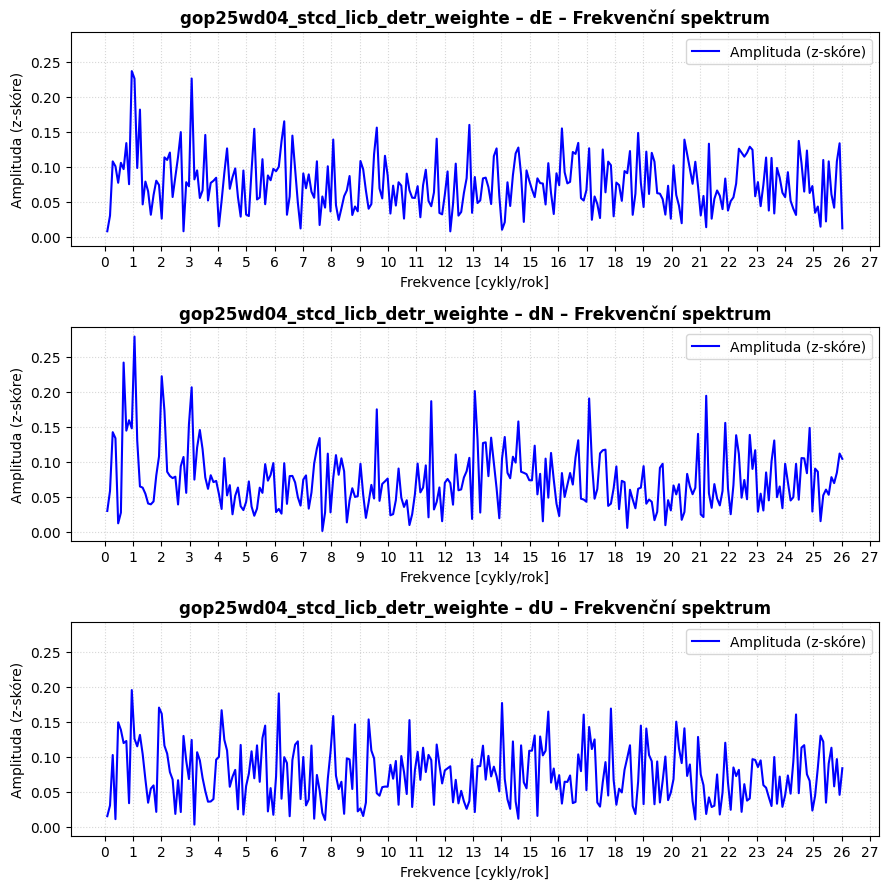

In [9]:
# --- Plot periodogram for each component (frequency in cycles/year) ---
fig, axes = plt.subplots(len(components), 1, figsize=(9, 9), sharex=False, sharey=True)
if len(components) == 1:
    axes = [axes]

df_all = pd.DataFrame()

for ax, comp in zip(axes, components):
    df_p = periodogram_results[comp]
    m = np.isfinite(df_p['frequency (cycles/year)'])
    df_plot = df_p.loc[m, ['frequency (cycles/year)', 'amplitude_z']]

    ax.plot(df_plot['frequency (cycles/year)'], df_plot['amplitude_z'], '-', color='blue', label='Amplituda (z-skóre)')
    ax.set_title(f"{Path(DETR_CSV).stem[:-10]} – {comp} – Frekvenční spektrum", fontweight='bold')
    ax.set_ylabel('Amplituda (z-skóre)')
    ax.set_xlabel('Frekvence [cykly/rok]')
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.legend()

    # --- Custom ticks: step = 1 cycles/year ---
    min_x = 0
    max_x = np.ceil(df_plot['frequency (cycles/year)'].max())
    ax.set_xticks(np.arange(min_x, max_x + 1, 1))

    df_all[comp] = df_plot['amplitude_z'].reset_index(drop=True)

plt.tight_layout()
image_file_name = f"{IMAGE_NAME}_amplitude_frequency"
fig.savefig(IMAGES_DIR / f"{image_file_name}.pdf", bbox_inches="tight")
plt.show()

### Plot amplitude spectrum  
Plots amplitude (in mm) of each component against its period (in years).

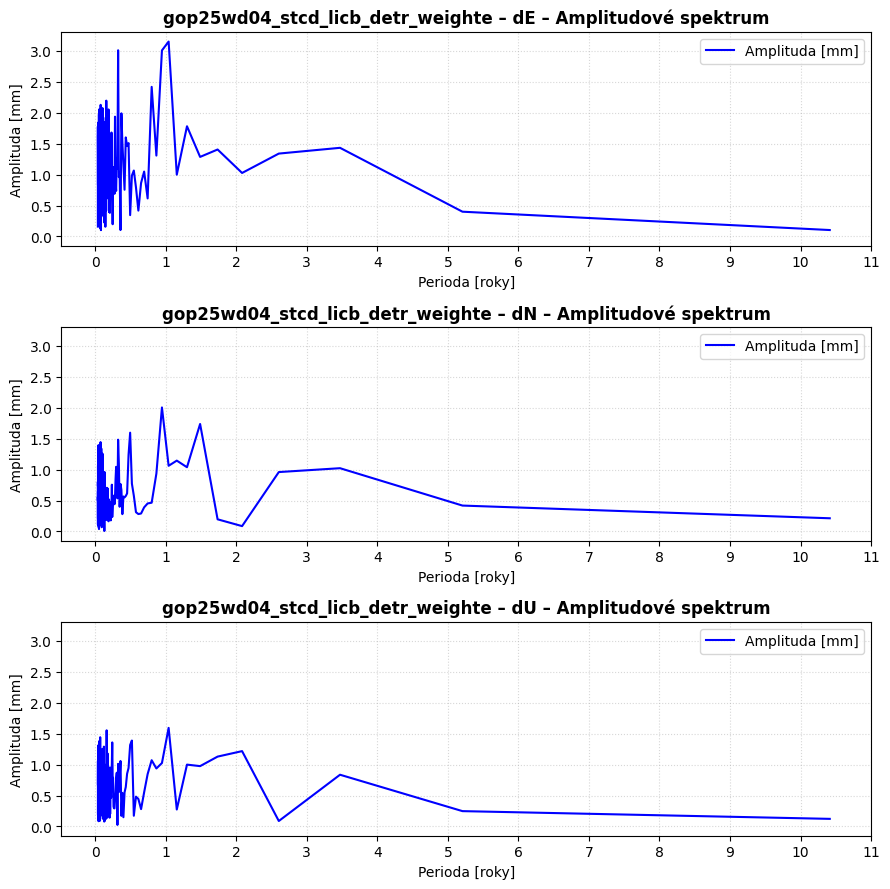

In [10]:
# --- Plot periodogram for each component (amplitude in mm) ---
fig, axes = plt.subplots(len(components), 1, figsize=(9, 9), sharex=False, sharey=True)
if len(components) == 1:
    axes = [axes]

df_all = pd.DataFrame()

for ax, comp in zip(axes, components):
    df_p = periodogram_results[comp]
    m = np.isfinite(df_p['period (years)'])
    df_plot = df_p.loc[m, ['period (years)', 'amplitude_mm']]

    ax.plot(df_plot['period (years)'], df_plot['amplitude_mm'], '-', color='blue', label='Amplituda [mm]')
    ax.set_title(f"{Path(DETR_CSV).stem[:-10]} – {comp} – Amplitudové spektrum", fontweight='bold')
    ax.set_ylabel('Amplituda [mm]')
    ax.set_xlabel('Perioda [roky]')
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.legend()

    # --- Custom ticks: step = 1 year ---
    min_x = 0
    max_x = np.ceil(df_plot['period (years)'].max())
    ax.set_xticks(np.arange(min_x, max_x + 1, 1))

    df_all[comp] = df_plot['amplitude_mm'].reset_index(drop=True)

plt.tight_layout()
image_file_name = f"{IMAGE_NAME}_amplitude_mm"
fig.savefig(IMAGES_DIR / f"{image_file_name}.pdf", bbox_inches="tight")
plt.show()

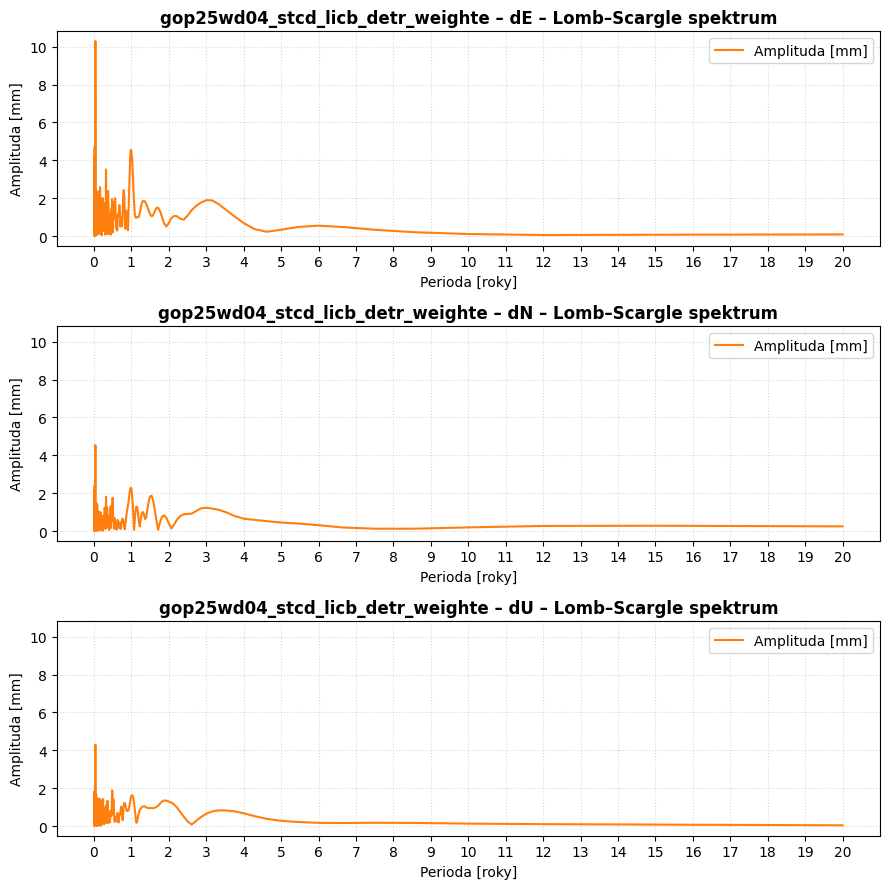

In [11]:
# --- Compute Lomb-Scargle periodogram using doris ---
# Lomb-Scargle handles unevenly sampled or gapped data; uses res_* residuals.
lomb_results = {}

for comp in components:
    _pg = _doris_pg(
        df_detr,
        method="lomb_scargle",
        time_col="t_year",
        value_cols=f"res_{comp}",
        min_period=0.01,
        max_period=20.0,
        n_frequencies=6000,
    )
    _pg["period (years)"]          = _pg["period"]
    _pg["frequency (cycles/year)"] = _pg["frequency"]
    _pg["amplitude_mm"]            = _pg["amplitude"]
    lomb_results[comp] = _pg

# --- Plot Lomb-Scargle amplitude spectrum ---
fig, axes = plt.subplots(len(components), 1, figsize=(9, 9), sharex=False, sharey=True)
if len(components) == 1:
    axes = [axes]

for ax, comp in zip(axes, components):
    df_p   = lomb_results[comp]
    m      = np.isfinite(df_p["period (years)"])
    df_plt = df_p.loc[m, ["period (years)", "amplitude_mm"]]

    ax.plot(df_plt["period (years)"], df_plt["amplitude_mm"],
            "-", color="tab:orange", label="Amplituda [mm]")
    ax.set_title(f"{Path(DETR_CSV).stem[:-10]} – {comp} – Lomb–Scargle spektrum",
                 fontweight="bold")
    ax.set_ylabel("Amplituda [mm]")
    ax.set_xlabel("Perioda [roky]")
    ax.grid(True, linestyle=":", alpha=0.5)
    ax.legend()

    max_x = np.ceil(df_plt["period (years)"].max())
    ax.set_xticks(np.arange(0, max_x + 1, 1))

plt.tight_layout()
fig.savefig(IMAGES_DIR / f"{IMAGE_NAME}_amplitude_mm_ls.pdf", bbox_inches="tight")
plt.show()

### Parameter Setup  
User-defined limits for minimum/maximum period (in years),  
number of dominant peaks per component, and prominence filter  
used for spectral peak detection in the reconstruction step.

In [12]:
# --- User parameters: period filtering and peak selection ---

# Define period limits [years]
MIN_PERIOD = 0.08     # lower bound for period (years)
MAX_PERIOD = 2.0    # upper bound for period (years)

# Number of dominant peaks (periodicities) to extract per component
TOP_K = {
    "dE": 3,         # number of peaks for North component
    "dN": 3,         # number of peaks for East component
    "dU": 3          # number of peaks for Up component
}

# Peak prominence control:
# "mean" = automatically use mean amplitude as threshold,
# or set numeric value (e.g. 0.05) for stricter filtering
PROMINENCE = "mean"

print("✅ Parameters set:")
print(f"  Period range: {MIN_PERIOD} – {MAX_PERIOD} years")
print(f"  Top peaks per component: {TOP_K}")
print(f"  Prominence filter: {PROMINENCE}")

✅ Parameters set:
  Period range: 0.08 – 2.0 years
  Top peaks per component: {'dE': 3, 'dN': 3, 'dU': 3}
  Prominence filter: mean


### Helper Function – Peak Selection  
Defines `select_top_peaks()` used to detect the most prominent spectral peaks  
within a specified period range, based on amplitude prominence.

In [13]:
# --- Helper function: select top peaks from spectrum -----------------------
def select_top_peaks(freqs, amps, periods, top_k=3,
                     min_period=None, max_period=None,
                     prominence="mean"):
    """
    Returns indices of top_k peaks in amplitude spectrum
    with optional period filtering and prominence threshold.
    """
    mask = np.isfinite(freqs) & np.isfinite(amps) & np.isfinite(periods)
    freqs, amps, periods = freqs[mask], amps[mask], periods[mask]
    valid_idx = np.where(mask)[0]

    # Filter by period range
    if min_period is not None:
        m2 = periods >= float(min_period)
        freqs, amps, periods, valid_idx = freqs[m2], amps[m2], periods[m2], valid_idx[m2]
    if max_period is not None:
        m3 = periods <= float(max_period)
        freqs, amps, periods, valid_idx = freqs[m3], amps[m3], periods[m3], valid_idx[m3]

    if len(amps) == 0:
        return np.array([], dtype=int)

    prom = float(np.mean(amps)) if prominence == "mean" else float(prominence)
    peaks, _ = find_peaks(amps, prominence=prom)

    if len(peaks) == 0:
        order = np.argsort(amps)[-min(top_k, len(amps)):]
        return valid_idx[order]

    order = np.argsort(amps[peaks])[-min(top_k, len(peaks)):]
    top_local = peaks[order]
    return valid_idx[top_local]

### Amplitude Spectrum with Selected Peaks  
Plots amplitude spectra (in mm) for each component and marks selected dominant peaks  
based on user-defined period range, number of peaks, and prominence threshold.

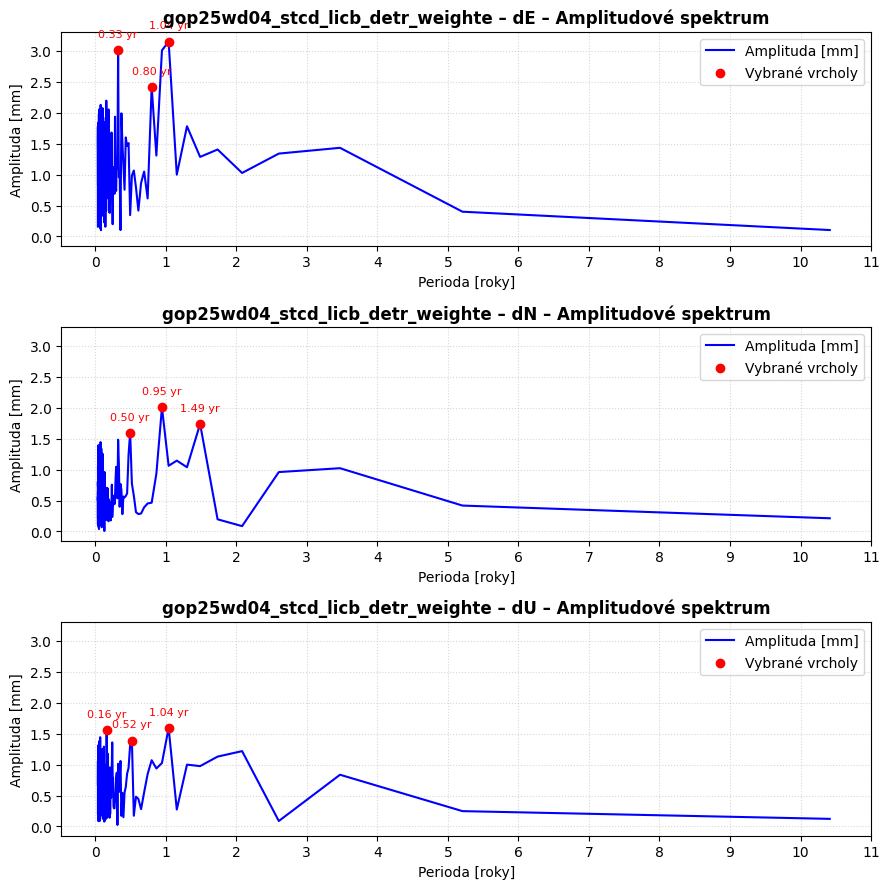

In [14]:
# --- Plot amplitude spectra with selected dominant peaks ---
fig, axes = plt.subplots(len(components), 1, figsize=(9, 9), sharex=False, sharey=True)
if len(components) == 1:
    axes = [axes]

df_all = pd.DataFrame()

for ax, comp in zip(axes, components):
    df_p = periodogram_results[comp]

    freqs   = df_p['frequency (cycles/year)'].values
    amps    = df_p['amplitude_mm'].values
    periods = df_p['period (years)'].values

    # --- Select peaks according to user parameters ---
    top_idx = select_top_peaks(
        freqs, amps, periods,
        top_k=TOP_K.get(comp, 1),
        min_period=MIN_PERIOD,
        max_period=MAX_PERIOD,
        prominence=PROMINENCE
    )

    # --- Base plot ---
    m = np.isfinite(periods)
    df_plot = df_p.loc[m, ['period (years)', 'amplitude_mm']]
    ax.plot(df_plot['period (years)'], df_plot['amplitude_mm'], '-', color='blue', label='Amplituda [mm]')

    # --- Highlight selected peaks ---
    if len(top_idx):
        ax.scatter(periods[top_idx], amps[top_idx], color='red', zorder=5, label='Vybrané vrcholy')
        for i in top_idx:
            ax.annotate(f"{periods[i]:.2f} yr",
                        (periods[i], amps[i]),
                        xytext=(0, 8), textcoords='offset points',
                        ha='center', va='bottom', color='red', fontsize=8,
                        linespacing=1.1)

    # --- Axis styling ---
    ax.set_title(f"{Path(DETR_CSV).stem[:-10]} – {comp} – Amplitudové spektrum", fontweight='bold')
    ax.set_ylabel('Amplituda [mm]')
    ax.set_xlabel('Perioda [roky]')
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.legend()

    # --- Custom ticks: step = 1 year ---
    min_x = 0
    max_x = np.ceil(df_plot['period (years)'].max())
    ax.set_xticks(np.arange(min_x, max_x + 1, 1))

    df_all[comp] = df_plot['amplitude_mm'].reset_index(drop=True)

plt.tight_layout()
image_file_name = f"{IMAGE_NAME}_amplitude_mm_peaks"
fig.savefig(IMAGES_DIR / f"{image_file_name}.pdf", bbox_inches="tight")
plt.show()

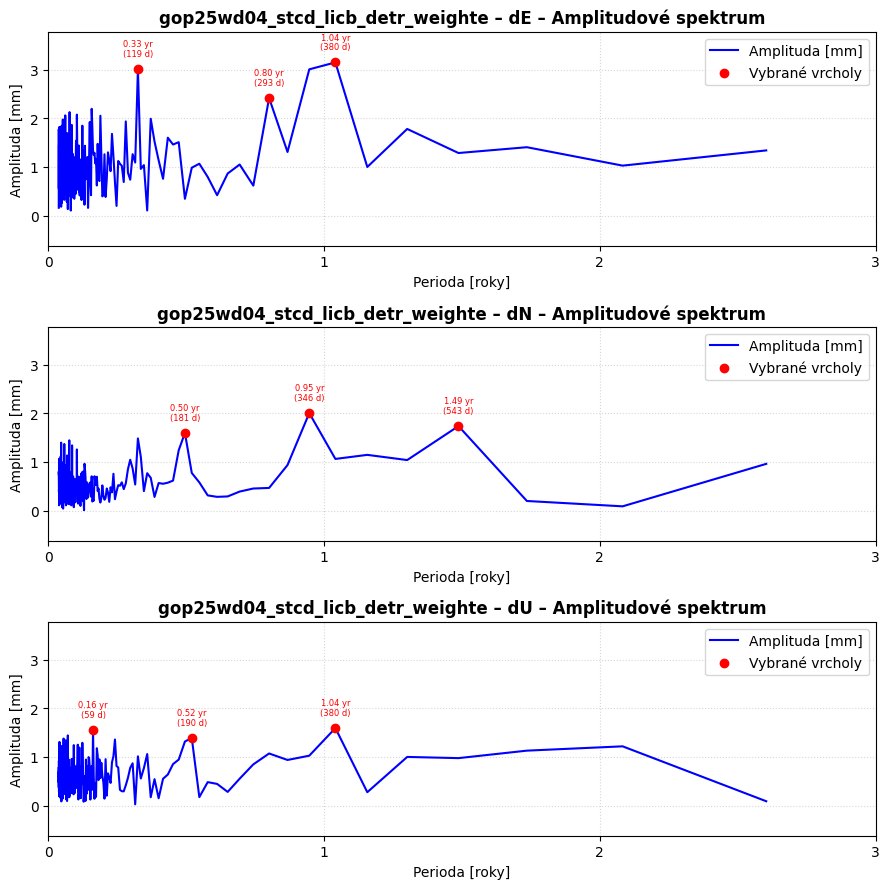

In [15]:
# --- Config: fraction of x-range to show (0 < frac <= 1) ---
PERIOD_VIEW_FRAC = 0.25   # dej 0.5 pro "první půlku", 1.0 pro celé

# --- Plot amplitude spectra with selected dominant peaks ---
fig, axes = plt.subplots(len(components), 1, figsize=(9, 9), sharex=False, sharey=True)
if len(components) == 1:
    axes = [axes]

df_all = pd.DataFrame()

for ax, comp in zip(axes, components):
    df_p = periodogram_results[comp]

    freqs   = df_p['frequency (cycles/year)'].values
    amps    = df_p['amplitude_mm'].values
    periods = df_p['period (years)'].values

    # --- Select peaks according to user parameters ---
    top_idx = select_top_peaks(
        freqs, amps, periods,
        top_k=TOP_K.get(comp, 1),
        min_period=MIN_PERIOD,
        max_period=MAX_PERIOD,
        prominence=PROMINENCE
    )

    # --- Base plot (apply x "zoom" by cropping to fraction) ---
    m = np.isfinite(periods)
    df_plot = df_p.loc[m, ['period (years)', 'amplitude_mm']]

    max_period = float(np.nanmax(df_plot['period (years)']))
    view_max   = max(0.0, PERIOD_VIEW_FRAC) * max_period  # clamp dolů
    view_max   = min(view_max, max_period)                # clamp nahoru

    # ořízni data na zobrazené okno
    m_view = df_plot['period (years)'] <= view_max if PERIOD_VIEW_FRAC < 1.0 else slice(None)
    ax.plot(df_plot.loc[m_view, 'period (years)'],
            df_plot.loc[m_view, 'amplitude_mm'],
            '-', color='blue', label='Amplituda [mm]')

    # --- Highlight selected peaks (jen ty, co spadají do zobrazeného okna) ---
    if len(top_idx):
        in_view = periods[top_idx] <= view_max if PERIOD_VIEW_FRAC < 1.0 else np.ones_like(top_idx, dtype=bool)
        vis_idx = np.array(top_idx)[in_view]

        if vis_idx.size:
            ax.scatter(periods[vis_idx], amps[vis_idx], color='red', zorder=5, label='Vybrané vrcholy')
            for i in vis_idx:
                days = int(round(periods[i] * 365.2425))
                ax.annotate(f"{periods[i]:.2f} yr\n({days} d)",
                #ax.annotate(f"{periods[i]:.2f} yr",
                            (periods[i], amps[i]),
                            xytext=(0, 8), textcoords='offset points',
                            ha='center', va='bottom', color='red', fontsize=6,
                            linespacing=1.1)

    # --- Axis styling ---
    ax.margins(y=0.2)
    ax.set_title(f"{Path(DETR_CSV).stem[:-10]} – {comp} – Amplitudové spektrum", fontweight='bold')
    ax.set_ylabel('Amplituda [mm]')
    ax.set_xlabel('Perioda [roky]')
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.legend()

    # --- X-limits + ticks ---
    ax.set_xlim(0, view_max if PERIOD_VIEW_FRAC < 1.0 else max_period)
    tick_max = np.ceil(view_max if PERIOD_VIEW_FRAC < 1.0 else max_period)
    ax.set_xticks(np.arange(0, tick_max + 1, 1))

    df_all[comp] = df_plot['amplitude_mm'].reset_index(drop=True)

plt.tight_layout()
image_file_name = f"{IMAGE_NAME}_amplitude_mm_peaks"
fig.savefig(IMAGES_DIR / f"{image_file_name}.pdf", bbox_inches="tight")
plt.show()

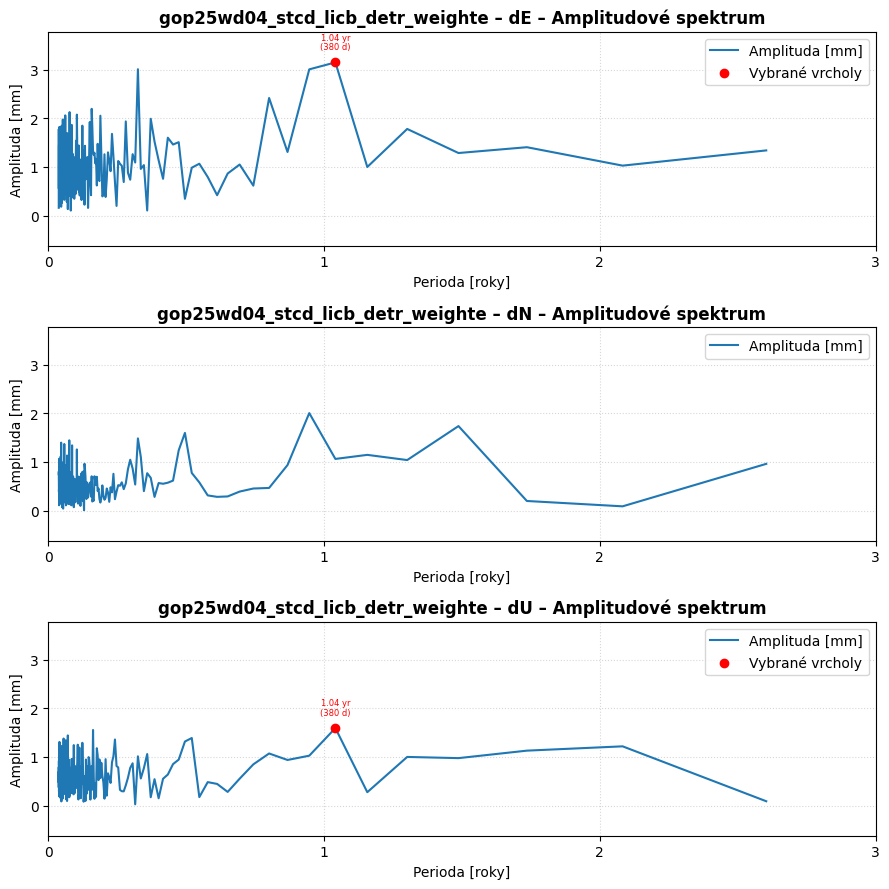

Saved PDF → C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\images\Stations\LICB\gop25wd04_stcd_licb_amplitude_mm_peaks.pdf


In [16]:
# ---------------------------- Config ---------------------------------------------------------
globals_dict     = globals()
PERIOD_VIEW_FRAC = float(globals_dict.get("PERIOD_VIEW_FRAC", 1.0))   # 1.0 = full x-range
MIN_PERIOD       = float(globals_dict.get("MIN_PERIOD", 0.1))
MAX_PERIOD       = float(globals_dict.get("MAX_PERIOD", 10.0))
PROMINENCE       = globals_dict.get("PROMINENCE", "mean")              # num | 'mean' | 'median' | 'pXX' | dict
TOP_K            = globals_dict.get("TOP_K", {})                        # dict per-comp for AUTO
DETR_CSV         = globals_dict.get("DETR_CSV", "dummy.csv")
IMAGE_NAME       = globals_dict.get("IMAGE_NAME", "spectral")
IMAGES_DIR       = Path(globals_dict.get("IMAGES_DIR", Path("images")))
components       = list(globals_dict.get("components", ["dE","dN","dU"]))

# Ruční periody (počet položek = kolik píků chceš; [] = žádný)
MANUAL_PERIODS = {
    # příklady: 'dE': [1.00, 0.5]
    "dE": [1],
    "dN": [],
    "dU": [1],
}

# tolerance přichycení (roky). None = vezmi vždy nejbližší lokální maximum.
SNAP_TOL_YEARS = 0.08

# ---------------------------- Global override storage ---------------------------------------
# Tuto mapu bude používat i Tvoje další buňka přes select_top_peaks(...).
PEAK_OVERRIDE_MAP = globals_dict.get("PEAK_OVERRIDE_MAP", {})
globals_dict["PEAK_OVERRIDE_MAP"] = PEAK_OVERRIDE_MAP  # expose for subsequent cells

def _array_signature(periods: np.ndarray, amps: np.ndarray, ndec: int = 6):
    """Stabilní signatura dvojice (periods, amps) – po zaokrouhlení."""
    p = np.asarray(periods, float)
    a = np.asarray(amps, float)
    if p.ndim != 1 or a.ndim != 1 or p.size != a.size:
        return ("RAW", p.tobytes(), a.tobytes())
    return ("RND", np.round(p, ndec).tobytes(), np.round(a, ndec).tobytes())

# ---------------------------- Helpers (safe) ------------------------------------------------
def _local_peak_indices(y: np.ndarray) -> np.ndarray:
    """Lokální maxima (ignoruje krajní body)."""
    y = np.asarray(y, dtype=float)
    yy = y.copy()
    yy[~np.isfinite(yy)] = -np.inf
    idx = np.arange(yy.size)
    return idx[1:-1][(yy[1:-1] > yy[:-2]) & (yy[1:-1] > yy[2:])]

def resolve_threshold(thr, amps: np.ndarray):
    """
    thr: číslo | 'mean' | 'median' | 'pXX' | dict | cokoliv → číslo nebo None (bez filtru).
    Dict bez znalosti komponenty ignorujeme (vrátíme None).
    """
    if isinstance(thr, (int, float)):
        return float(thr) if np.isfinite(thr) else None
    if isinstance(thr, str):
        s = thr.strip().lower()
        if s == "mean":   return float(np.nanmean(amps))
        if s == "median": return float(np.nanmedian(amps))
        if s.startswith("p"):
            try:
                q = float(s[1:])
                return float(np.nanpercentile(amps, q))
            except Exception:
                return None
    # dict nebo jiný typ → bez filtru v této generické verzi
    return None

def select_top_peaks(freqs, amps, periods, top_k=1, min_period=0.0, max_period=np.inf, prominence=None):
    """
    AUTO volba píků s RESPEKTEM k ručnímu override (PEAK_OVERRIDE_MAP):
      1) pokud existuje override pro (periods, amps) → vrátí přesně tyto indexy (i prázdné);
      2) jinak: lokální maxima v intervalu period + filtr minimální amplitudou.
    """
    freqs   = np.asarray(freqs,   float)
    amps    = np.asarray(amps,    float)
    periods = np.asarray(periods, float)

    sig = _array_signature(periods, amps)
    if sig in PEAK_OVERRIDE_MAP:
        return np.asarray(PEAK_OVERRIDE_MAP[sig], dtype=int)

    peaks = _local_peak_indices(amps)
    if peaks.size == 0:
        return np.array([], dtype=int)

    in_range = (periods[peaks] >= float(min_period)) & (periods[peaks] <= float(max_period))
    peaks = peaks[in_range]
    if peaks.size == 0:
        return np.array([], dtype=int)

    min_amp = resolve_threshold(prominence, amps)
    if (min_amp is not None) and np.isfinite(min_amp):
        peaks = peaks[amps[peaks] >= float(min_amp)]
        if peaks.size == 0:
            return np.array([], dtype=int)

    order = np.argsort(amps[peaks])[::-1]
    peaks = peaks[order]
    if (top_k is None) or (top_k <= 0) or (top_k > peaks.size):
        top_k = peaks.size
    return peaks[:top_k].astype(int)

def snap_periods_to_peaks(periods: np.ndarray, amps: np.ndarray, wanted_periods, tol_years=None) -> np.ndarray:
    """Přichyť každou požadovanou periodu k nejbližšímu lokálnímu maximu (s tolerancí)."""
    periods = np.asarray(periods, float)
    amps    = np.asarray(amps, float)
    peaks = _local_peak_indices(amps)
    if peaks.size == 0:
        return np.array([], dtype=int)
    out = []
    seq = list(wanted_periods) if np.ndim(wanted_periods) else [wanted_periods]
    for P in seq:
        P = float(P)
        j = int(np.argmin(np.abs(periods[peaks] - P)))
        if (tol_years is None) or (abs(periods[peaks][j] - P) <= float(tol_years)):
            out.append(int(peaks[j]))
    return np.array(sorted(set(out)), dtype=int)

# ---------------------------- Plot + store overrides ----------------------------------------
if "periodogram_results" not in globals_dict:
    raise RuntimeError("Chybí 'periodogram_results' (dict[comp] -> DataFrame s period/freq/amp).")

fig, axes = plt.subplots(len(components), 1, figsize=(9, 9), sharex=False, sharey=True)
if len(components) == 1:
    axes = [axes]

for ax, comp in zip(axes, components):
    df_p = globals_dict["periodogram_results"][comp]
    freqs   = pd.to_numeric(df_p['frequency (cycles/year)'], errors="coerce").to_numpy()
    amps    = pd.to_numeric(df_p['amplitude_mm'],          errors="coerce").to_numpy()
    periods = pd.to_numeric(df_p['period (years)'],        errors="coerce").to_numpy()

    # --- MANUAL first: pokud existuje položka v MANUAL_PERIODS, použij ji přes "snap" ---
    manual_list = MANUAL_PERIODS.get(comp, None)  # None → použij AUTO, [] → explicitně nic
    if manual_list is not None:
        top_idx = snap_periods_to_peaks(periods, amps, manual_list, tol_years=SNAP_TOL_YEARS) if len(manual_list) else np.array([], dtype=int)
    else:
        # --- AUTO fallback: TOP_K + PROMINENCE (může být dict/str/num) ---
        prom_cfg = PROMINENCE.get(comp, PROMINENCE) if isinstance(PROMINENCE, dict) else PROMINENCE
        prom_val = resolve_threshold(prom_cfg, amps)
        top_idx  = select_top_peaks(freqs, amps, periods,
                                    top_k=int(TOP_K.get(comp, 1)),
                                    min_period=MIN_PERIOD,
                                    max_period=MAX_PERIOD,
                                    prominence=prom_val)

    # --- Ulož do globálního override, aby další buňky dostaly stejné indexy -----------------
    sig = _array_signature(periods, amps)
    PEAK_OVERRIDE_MAP[sig] = np.array(top_idx, dtype=int)

    # --- Plot (s možností zoomu do části osy X) ---------------------------------------------
    m = np.isfinite(periods) & np.isfinite(amps)
    p = periods[m]; a = amps[m]
    if p.size == 0:
        ax.set_visible(False); continue

    max_period = float(np.nanmax(p))
    view_max   = max_period if PERIOD_VIEW_FRAC >= 1.0 else max(0.0, PERIOD_VIEW_FRAC) * max_period
    in_view    = (p <= view_max) if PERIOD_VIEW_FRAC < 1.0 else np.ones_like(p, dtype=bool)

    ax.plot(p[in_view], a[in_view], '-', label='Amplituda [mm]')

    # zvýrazni vybrané peaky (jen ty, co spadají do zobrazeného okna)
    if top_idx.size:
        vis_idx = top_idx[periods[top_idx] <= view_max] if PERIOD_VIEW_FRAC < 1.0 else top_idx
        if vis_idx.size:
            ax.scatter(periods[vis_idx], amps[vis_idx], color='red', zorder=5, label='Vybrané vrcholy')
            for i in vis_idx:
                days = int(round(periods[i] * 365.2425))
                ax.annotate(f"{periods[i]:.2f} yr\n({days} d)",
                            (periods[i], amps[i]), xytext=(0, 8), textcoords='offset points',
                            ha='center', va='bottom', color='red', fontsize=6, linespacing=1.1)

    # styling + osy
    ax.margins(y=0.2)
    stem = Path(DETR_CSV).stem[:-10] if len(Path(DETR_CSV).stem) >= 10 else Path(DETR_CSV).stem
    ax.set_title(f"{stem} – {comp} – Amplitudové spektrum", fontweight='bold')
    ax.set_ylabel('Amplituda [mm]')
    ax.set_xlabel('Perioda [roky]')
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.legend()
    ax.set_xlim(0, view_max)
    ax.set_xticks(np.arange(0, int(np.ceil(view_max)) + 1, 1))

plt.tight_layout()
IMAGES_DIR.mkdir(parents=True, exist_ok=True)
outname = f"{IMAGE_NAME}_amplitude_mm_peaks"
plt.savefig(IMAGES_DIR / f"{outname}.pdf", bbox_inches="tight")
plt.show()

print("Saved PDF →", IMAGES_DIR / f"{outname}.pdf")


### Selected Periodic Components  
Plots reconstructed sinusoidal components for each displacement axis (dN, dE, dU)  
based on user-defined period limits and number of selected peaks.

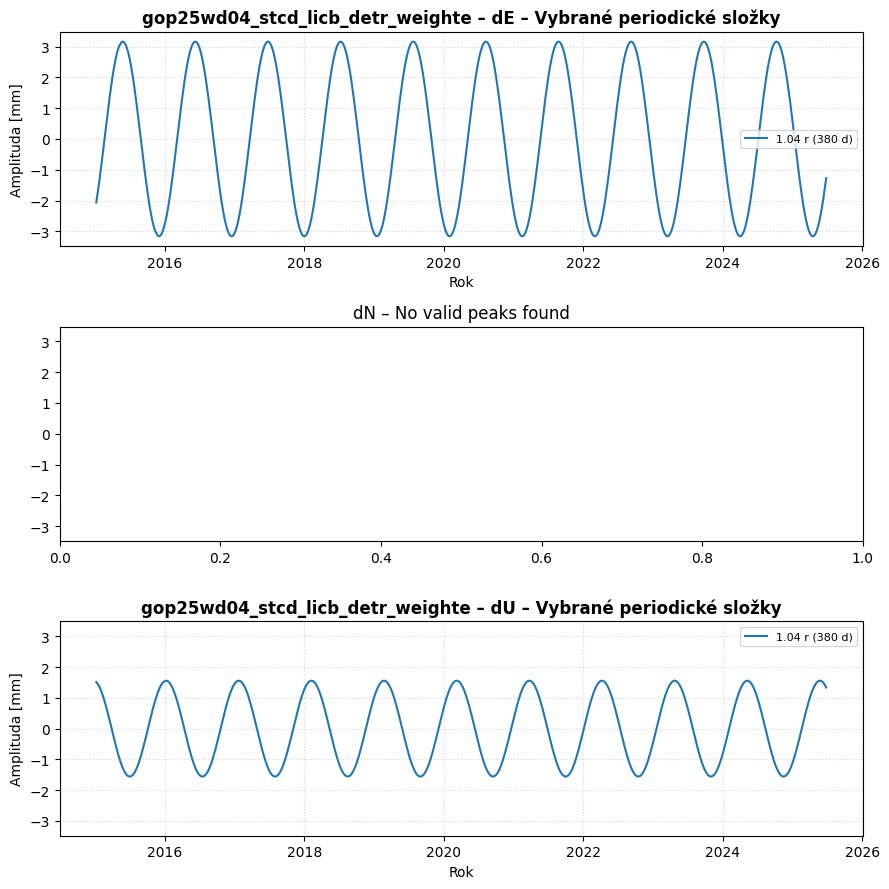

In [17]:
# --- Plot selected periodic components for each axis ---
fig, axes = plt.subplots(len(components), 1, figsize=(9, 9), sharex=False, sharey=True)
if len(components) == 1:
    axes = [axes]

for ax, comp in zip(axes, components):
    df_p = periodogram_results[comp]
    freqs   = df_p['frequency (cycles/year)'].values
    amps    = df_p['amplitude_mm'].values
    periods = df_p['period (years)'].values

    # --- Select peaks according to current user parameters ---
    peak_idx = select_top_peaks(
        freqs, amps, periods,
        top_k=TOP_K.get(comp, 1),
        min_period=MIN_PERIOD,
        max_period=MAX_PERIOD,
        prominence=PROMINENCE
    )

    # --- Original signal (for time axis reference) ---
    time = df_detr['year'].dropna().values[:len(df_detr[f'res_{comp}'].dropna())]
    signal = df_detr[f'res_{comp}'].dropna().values
    if len(signal) == 0 or len(peak_idx) == 0:
        ax.set_title(f"{comp} – No valid peaks found")
        continue

    # --- Least-squares periodic reconstruction (sin+cos basis per period) ---
    _t0   = time[0]
    _dper = periods[peak_idx]
    _cols = [np.ones_like(time)]
    for _p in _dper:
        _w = 2 * np.pi / _p
        _cols.append(np.sin(_w * (time - _t0)))
        _cols.append(np.cos(_w * (time - _t0)))
    _A = np.column_stack(_cols)
    _coef, *_ = np.linalg.lstsq(_A, signal, rcond=None)
    for _i, _p in enumerate(_dper):
        _w = 2 * np.pi / _p
        _y = (_coef[1 + 2*_i] * np.sin(_w * (time - _t0))
              + _coef[2 + 2*_i] * np.cos(_w * (time - _t0)))
        ax.plot(time, _y, label=f"{_p:.2f} r ({_p*365.25:.0f} d)")

    ax.set_title(f"{Path(DETR_CSV).stem[:-10]} – {comp} – Vybrané periodické složky", fontweight='bold')
    ax.set_xlabel('Rok')
    ax.set_ylabel('Amplituda [mm]')
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.legend(fontsize=8)

plt.tight_layout()
image_file_name = f"{IMAGE_NAME}_selected_periodic_components"
fig.savefig(IMAGES_DIR / f"{image_file_name}.pdf", bbox_inches="tight")
plt.show()

### Summed Periodic Signal  
Plots the reconstructed signal formed by summing all selected periodic components  
for each displacement axis. The black line shows the original data, red the periodic fit.

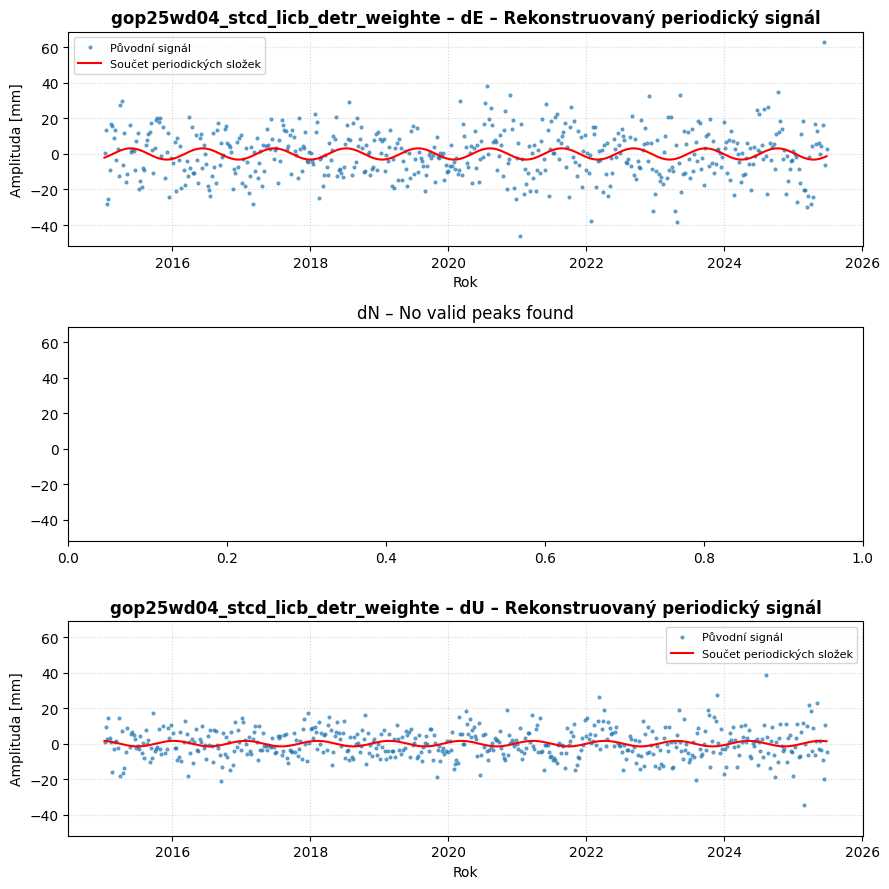

In [18]:
# --- Plot sum of selected periodic components for each axis ---
fig, axes = plt.subplots(len(components), 1, figsize=(9, 9), sharex=False, sharey=True)
if len(components) == 1:
    axes = [axes]

for ax, comp in zip(axes, components):
    df_p = periodogram_results[comp]
    freqs   = df_p['frequency (cycles/year)'].values
    amps    = df_p['amplitude_mm'].values
    periods = df_p['period (years)'].values

    # --- Select peaks according to user parameters ---
    peak_idx = select_top_peaks(
        freqs, amps, periods,
        top_k=TOP_K.get(comp, 1),
        min_period=MIN_PERIOD,
        max_period=MAX_PERIOD,
        prominence=PROMINENCE
    )

    # --- Original signal and time vector ---
    time = df_detr['year'].dropna().values[:len(df_detr[f'res_{comp}'].dropna())]
    signal = df_detr[f'res_{comp}'].dropna().values
    if len(signal) == 0 or len(peak_idx) == 0:
        ax.set_title(f"{comp} – No valid peaks found")
        continue

    # --- Least-squares periodic reconstruction ---
    _t0   = time[0]
    _dper = periods[peak_idx]
    _cols = [np.ones_like(time)]
    for _p in _dper:
        _w = 2 * np.pi / _p
        _cols.append(np.sin(_w * (time - _t0)))
        _cols.append(np.cos(_w * (time - _t0)))
    _A = np.column_stack(_cols)
    _coef, *_ = np.linalg.lstsq(_A, signal, rcond=None)
    y_components = np.zeros((len(time), len(peak_idx)))
    for _i, _p in enumerate(_dper):
        _w = 2 * np.pi / _p
        y_components[:, _i] = (_coef[1 + 2*_i] * np.sin(_w * (time - _t0))
                               + _coef[2 + 2*_i] * np.cos(_w * (time - _t0)))
    y_sum = np.sum(y_components, axis=1)

    # --- Plot reconstructed (summed) periodic signal ---
    ax.plot(time, signal, '.', ms=4, alpha=0.6, label='Původní signál')
    ax.plot(time, y_sum, color='red', label='Součet periodických složek')
    ax.set_title(f"{Path(DETR_CSV).stem[:-10]} – {comp} – Rekonstruovaný periodický signál", fontweight='bold')
    ax.set_xlabel('Rok')
    ax.set_ylabel('Amplituda [mm]')
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.legend(fontsize=8)

plt.tight_layout()
image_file_name = f"{IMAGE_NAME}_sum_periodic_components"
fig.savefig(IMAGES_DIR / f"{image_file_name}.pdf", bbox_inches="tight")
plt.show()

### Reconstruct & aperiodic series
Rebuild the periodic part from selected spectral peaks, subtract it from residuals, and plot the aperiodic points.  
Adds `aper_dE`, `aper_dN`, `aper_dU` to `df_aper` and saves the figure.

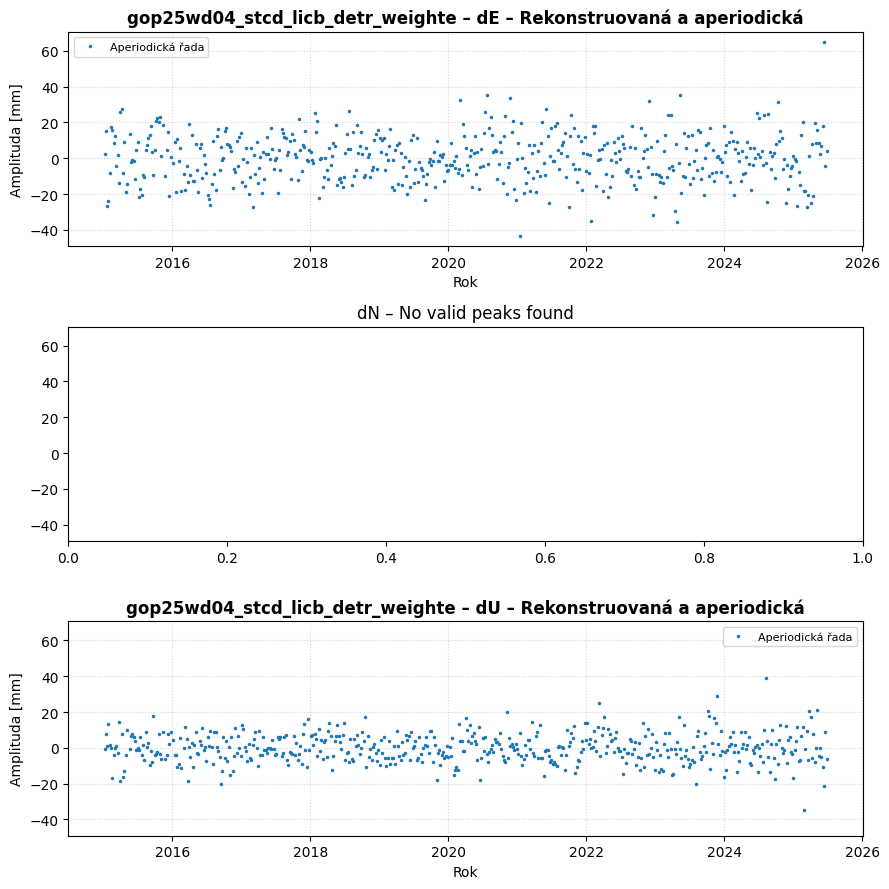

✅ df_aper columns added: ['aper_dE', 'aper_dN', 'aper_dU']


,Date,dE,dN,dU,sE,sN,sU,year,fit_dE,res_dE,...,seg_dN,fit_dU,res_dU,seg_dU,t_year,res_dE_std,res_dN_std,res_dU_std,aper_dE,aper_dU
0,2015-01-07 12:00:00,333.1,279.0,-3.4,8.2,3.4,4.8,2015.017808,332.601115,0.498885,...,0,-4.183761,0.783761,0,0.000000,0.035812,-0.594433,0.094721,2.566434,-0.727806
1,2015-01-14 12:00:00,346.4,276.7,5.1,7.8,3.4,4.9,2015.036986,333.038814,13.361186,...,0,-4.253971,9.353971,0,0.019178,1.002787,-0.953329,1.145929,15.138477,7.895903
2,2015-01-21 12:00:00,305.3,275.2,-1.7,8.6,3.6,5.2,2015.056164,333.476512,-28.176512,...,0,-4.324181,2.624181,0,0.038356,-2.119974,-1.200833,0.320464,-26.713250,1.239112
3,2015-01-28 12:00:00,308.6,275.0,10.3,8.4,3.5,5.0,2015.075342,333.914210,-25.314210,...,0,-4.394391,14.694391,0,0.057534,-1.904789,-1.267323,1.800976,-24.184548,13.400845
4,2015-02-04 12:00:00,325.1,278.2,-1.4,8.2,3.4,5.1,2015.094521,334.351908,-9.251908,...,0,-4.464601,3.064601,0,0.076713,-0.697242,-0.860394,0.374485,-8.470972,1.879885


In [19]:
# --- Reconstruct periodic part, plot, and build df_aper ----
time_col = "year"
df_aper = df_detr.copy()  # same shape as df_detr; we'll add aper_* columns

fig, axes = plt.subplots(len(components), 1, figsize=(9, 9), sharex=False, sharey=True)
if len(components) == 1: axes = [axes]

for ax, comp in zip(axes, components):
    # periodogram inputs
    df_p     = periodogram_results[comp]
    freqs    = df_p['frequency (cycles/year)'].to_numpy()
    amps_mm  = df_p['amplitude_mm'].to_numpy()
    periods  = df_p['period (years)'].to_numpy()

    # selected peaks (your function + params)
    peak_idx = select_top_peaks(
        freqs, amps_mm, periods,
        top_k=TOP_K.get(comp, 1),
        min_period=MIN_PERIOD,
        max_period=MAX_PERIOD,
        prominence=PROMINENCE
    )

    # original residual signal (align time & data)
    t = df_detr[time_col].to_numpy()
    y = df_detr[f"res_{comp}"].to_numpy()
    m = np.isfinite(t) & np.isfinite(y)
    t = t[m]; y = y[m]
    if t.size == 0 or len(peak_idx) == 0:
        ax.set_title(f"{comp} – No valid peaks found"); continue

    # Least-squares periodic reconstruction (sin+cos basis per period)
    _t0   = t[0]
    _dper = periodogram_results[comp]["period (years)"].to_numpy()[peak_idx]
    _cols = [np.ones_like(t)]
    for _p in _dper:
        _w = 2 * np.pi / _p
        _cols.append(np.sin(_w * (t - _t0)))
        _cols.append(np.cos(_w * (t - _t0)))
    _A = np.column_stack(_cols)
    _coef, *_ = np.linalg.lstsq(_A, y, rcond=None)
    y_sum   = _A[:, 1:] @ _coef[1:]
    y_clean = y - y_sum   # aperiodic = residual minus periodic

    # plot aperiodic
    ax.plot(t, y_clean, ".", ms=3, label="Aperiodická řada")

    ax.set_title(f"{Path(DETR_CSV).stem[:-10]} – {comp} – Rekonstruovaná a aperiodická", fontweight="bold")
    ax.set_xlabel("Rok"); ax.set_ylabel("Amplituda [mm]")
    ax.grid(True, linestyle=":", alpha=0.5); ax.legend(fontsize=8)

    # write back to df_aper (align by mask m)
    df_aper.loc[m, f"aper_{comp}"] = y_clean



plt.tight_layout()
image_file_name = f"{IMAGE_NAME}_sum_periodic_components_with_aper"
fig.savefig(IMAGES_DIR / f"{image_file_name}.pdf", bbox_inches="tight")
plt.show()

print("✅ df_aper columns added:", [f"aper_{c}" for c in components])
df_aper.head()  # optional peek

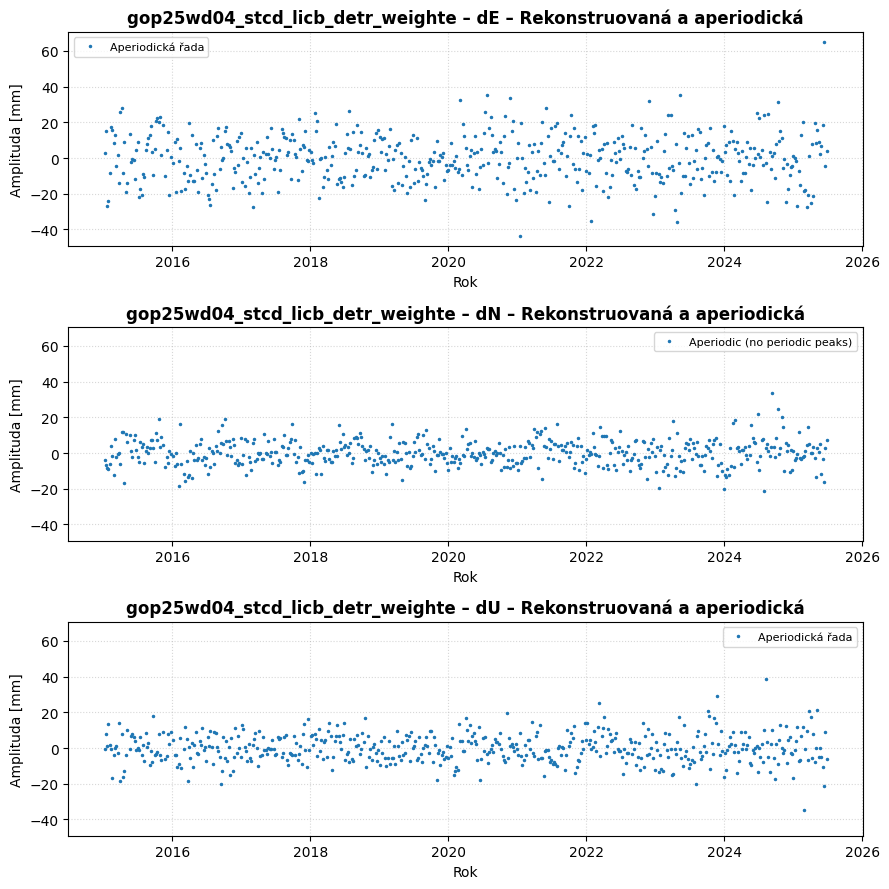

✅ df_aper columns added: ['aper_dE', 'aper_dN', 'aper_dU']


In [20]:
# --- Reconstruct periodic part, plot, and build df_aper ----
time_col = "year"
df_aper = df_detr.copy()

fig, axes = plt.subplots(len(components), 1, figsize=(9, 9), sharex=False, sharey=True)
if len(components) == 1:
    axes = [axes]

for ax, comp in zip(axes, components):
    df_p     = periodogram_results[comp]
    freqs    = df_p['frequency (cycles/year)'].to_numpy()
    amps_mm  = df_p['amplitude_mm'].to_numpy()
    periods  = df_p['period (years)'].to_numpy()

    peak_idx = select_top_peaks(
        freqs, amps_mm, periods,
        top_k=TOP_K.get(comp, 1),
        min_period=MIN_PERIOD,
        max_period=MAX_PERIOD,
        prominence=PROMINENCE
    )

    t = df_detr[time_col].to_numpy()
    y = df_detr[f"res_{comp}"].to_numpy()
    m = np.isfinite(t) & np.isfinite(y)
    t = t[m]; y = y[m]

    if t.size == 0:
        ax.set_title(f"{comp} – No data"); ax.set_xlabel("Rok"); ax.set_ylabel("Amplituda [mm]")
        ax.grid(True, linestyle=":", alpha=0.5)
        continue

    if len(peak_idx) == 0:
        # žádné peaky → nic neodečítám
        y_clean = y.copy()
        lbl = "Aperiodic (no periodic peaks)"
    else:
        # Least-squares periodic reconstruction (sin+cos basis per period)
        _t0   = t[0]
        _dper = periodogram_results[comp]["period (years)"].to_numpy()[peak_idx]
        _cols = [np.ones_like(t)]
        for _p in _dper:
            _w = 2 * np.pi / _p
            _cols.append(np.sin(_w * (t - _t0)))
            _cols.append(np.cos(_w * (t - _t0)))
        _A = np.column_stack(_cols)
        _coef, *_ = np.linalg.lstsq(_A, y, rcond=None)
        y_sum   = _A[:, 1:] @ _coef[1:]
        y_clean = y - y_sum
        lbl = "Aperiodická řada"

    # plot aperiodic (vždy něco vykreslím)
    ax.plot(t, y_clean, ".", ms=3, label=lbl)
    ax.set_title(f"{Path(DETR_CSV).stem[:-10]} – {comp} – Rekonstruovaná a aperiodická", fontweight="bold")
    ax.set_xlabel("Rok"); ax.set_ylabel("Amplituda [mm]")
    ax.grid(True, linestyle=":", alpha=0.5); ax.legend(fontsize=8)

    # zapiš do df_aper
    df_aper.loc[m, f"aper_{comp}"] = y_clean

plt.tight_layout()
image_file_name = f"{IMAGE_NAME}_sum_periodic_components_with_aper"
fig.savefig(IMAGES_DIR / f"{image_file_name}.pdf", bbox_inches="tight")
plt.show()

print("✅ df_aper columns added:", [f"aper_{c}" for c in components])

### Plot Selected Periodicities  
Reconstructs and visualizes dominant periodic components for each displacement axis.  
Displays amplitude spectrum with marked peaks, individual harmonic components,  
reconstructed signal, original data, and residuals after periodicity removal.


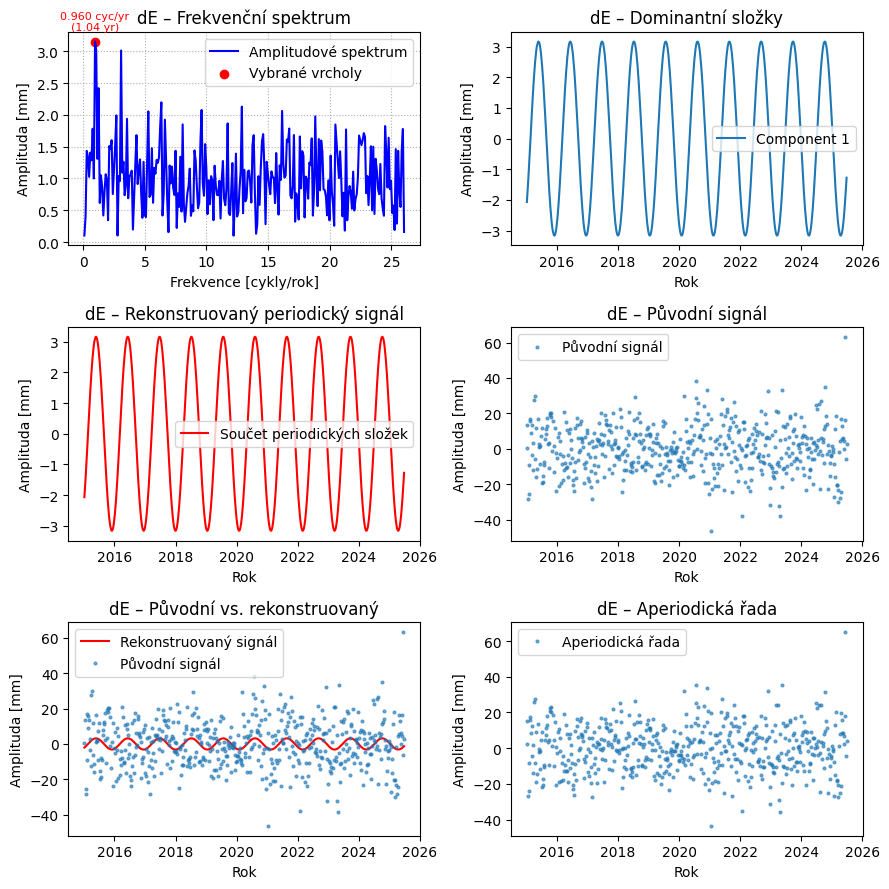

⚠️ No valid data or peaks found for component dN


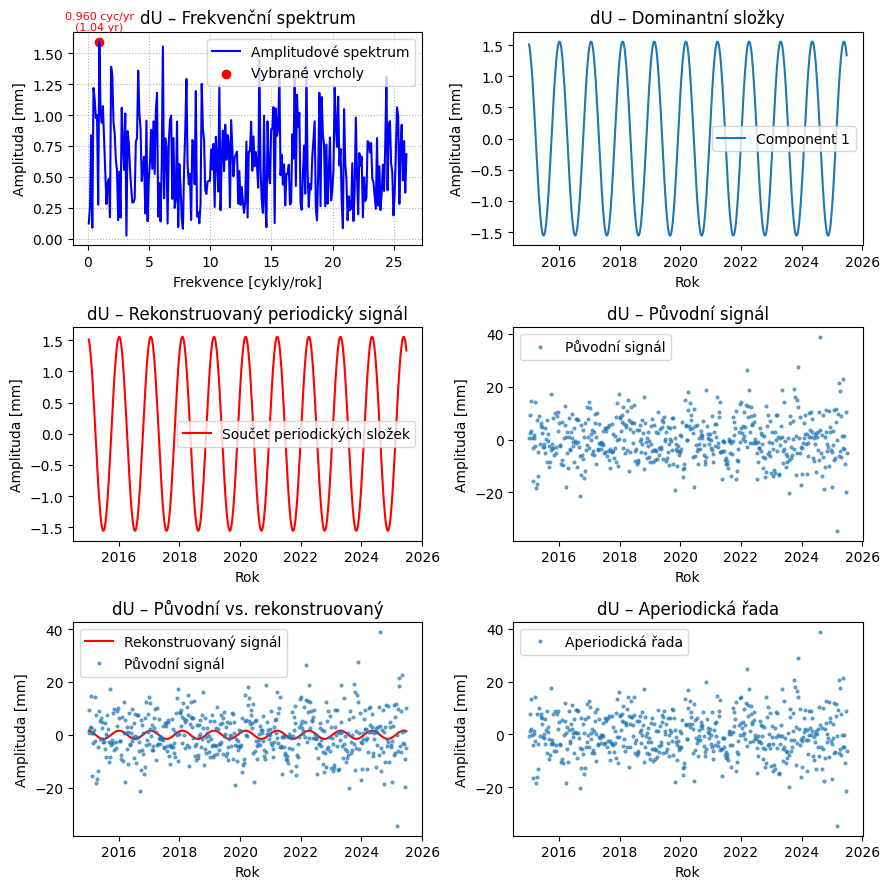

In [21]:
# --- Plot selected periodicities for each component ---

for comp in components:
    df_p = periodogram_results[comp]
    freqs   = df_p['frequency (cycles/year)'].values
    amps    = df_p['amplitude_mm'].values
    periods = df_p['period (years)'].values

    # --- Select dominant peaks according to current parameters ---
    peak_idx = select_top_peaks(
        freqs, amps, periods,
        top_k=TOP_K.get(comp, 1),
        min_period=MIN_PERIOD,
        max_period=MAX_PERIOD,
        prominence=PROMINENCE
    )

    # --- Original signal ---
    time = df_detr['year'].dropna().values[:len(df_detr[f'res_{comp}'].dropna())]
    signal = df_detr[f'res_{comp}'].dropna().values
    N = len(signal)
    if N == 0 or len(peak_idx) == 0:
        print(f"⚠️ No valid data or peaks found for component {comp}")
        continue

    # --- Least-squares periodic reconstruction ---
    _t0   = time[0]
    _dper = periods[peak_idx]
    _cols = [np.ones_like(time)]
    for _p in _dper:
        _w = 2 * np.pi / _p
        _cols.append(np.sin(_w * (time - _t0)))
        _cols.append(np.cos(_w * (time - _t0)))
    _A = np.column_stack(_cols)
    _coef, *_ = np.linalg.lstsq(_A, signal, rcond=None)
    y_components = np.zeros((N, len(peak_idx)))
    for _i, _p in enumerate(_dper):
        _w = 2 * np.pi / _p
        y_components[:, _i] = (_coef[1 + 2*_i] * np.sin(_w * (time - _t0))
                               + _coef[2 + 2*_i] * np.cos(_w * (time - _t0)))
    y_sum = np.sum(y_components, axis=1)

    # --- Plot overview (6 panels) ---
    plt.figure(figsize=(9, 9))

    # 1) Spectrum with peaks
    plt.subplot(3, 2, 1)
    plt.plot(freqs, amps, 'b-', label='Amplitudové spektrum')
    plt.scatter(freqs[peak_idx], amps[peak_idx], color='red', label='Vybrané vrcholy')
    for idx in peak_idx:
        plt.annotate(f"{freqs[idx]:.3f} cyc/yr\n({periods[idx]:.2f} yr)",
                     (freqs[idx], amps[idx]), xytext=(0, 8),
                     textcoords="offset points", ha='center', color='red', fontsize=8)
    plt.title(f"{comp} – Frekvenční spektrum")
    plt.xlabel('Frekvence [cykly/rok]')
    plt.ylabel('Amplituda [mm]')
    plt.grid(True, linestyle=':')
    plt.legend()

    # 2) Dominant components
    plt.subplot(3, 2, 2)
    for i in range(len(peak_idx)):
        plt.plot(time, y_components[:, i], label=f'Component {i+1}')
    plt.title(f"{comp} – Dominantní složky")
    plt.xlabel('Rok'); plt.ylabel('Amplituda [mm]')
    plt.legend()

    # 3) Reconstructed signal
    plt.subplot(3, 2, 3)
    plt.plot(time, y_sum, 'r', label='Součet periodických složek')
    plt.title(f"{comp} – Rekonstruovaný periodický signál")
    plt.xlabel('Rok'); plt.ylabel('Amplituda [mm]')
    plt.legend()

    # 4) Original signal
    plt.subplot(3, 2, 4)
    plt.plot(time, signal, '.', ms=4, alpha=0.6, label='Původní signál',)
    plt.title(f"{comp} – Původní signál")
    plt.xlabel('Rok'); plt.ylabel('Amplituda [mm]')
    plt.legend()
    
    # 5) Original vs reconstructed
    plt.subplot(3, 2, 5)
    plt.plot(time, y_sum, 'r', label='Rekonstruovaný signál',)
    plt.plot(time, signal, '.', ms=4, alpha=0.6, label='Původní signál',)
    plt.title(f"{comp} – Původní vs. rekonstruovaný")
    plt.xlabel('Rok'); plt.ylabel('Amplituda [mm]')
    plt.legend()

    # 6) Residual (without periodicity)
    plt.subplot(3, 2, 6)
    plt.plot(time, signal - y_sum, '.', ms=4, alpha=0.6, label='Aperiodická řada')
    plt.title(f"{comp} – Aperiodická řada")
    plt.xlabel('Rok'); plt.ylabel('Amplituda [mm]')
    plt.legend()

    plt.tight_layout()
    # image_file_name = f"{IMAGE_NAME}_periodic_overwiev"
    # fig.savefig(IMAGES_DIR / f"{image_file_name}.pdf", bbox_inches="tight")
    plt.show()

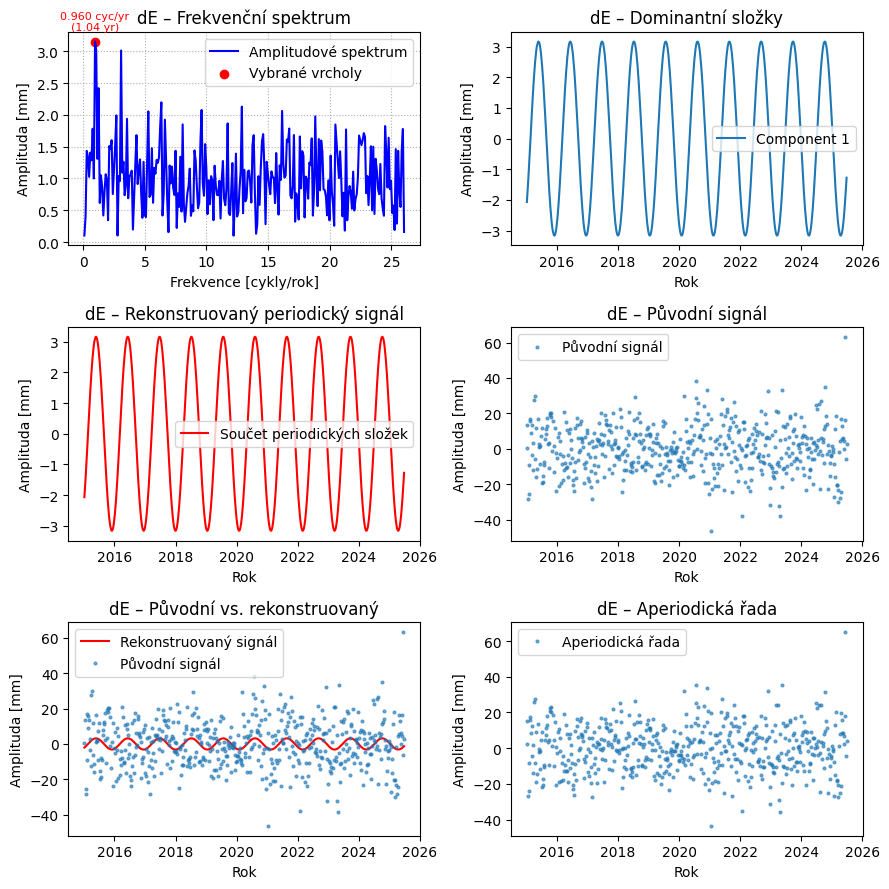

Saved → C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\images\Stations\LICB\gop25wd04_stcd_licb_dE_periodic_overview.pdf
⚠️ No valid data or peaks for dN


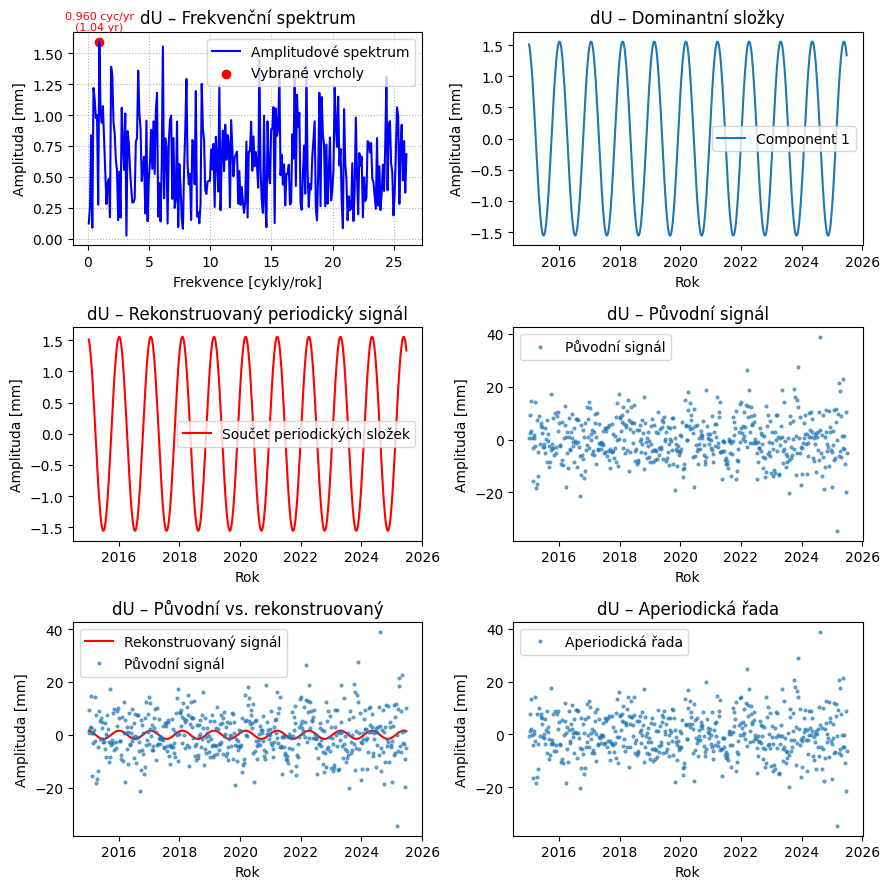

Saved → C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\images\Stations\LICB\gop25wd04_stcd_licb_dU_periodic_overview.pdf


In [22]:
# --- Plot selected periodicities for each component (save per component) ---
for comp in components:  # e.g. ["dE"] nebo ["dE","dN","dU"]
    df_p    = periodogram_results[comp]
    freqs   = df_p['frequency (cycles/year)'].values
    amps    = df_p['amplitude_mm'].values
    periods = df_p['period (years)'].values

    peak_idx = select_top_peaks(
        freqs, amps, periods,
        top_k=TOP_K.get(comp, 1),
        min_period=MIN_PERIOD,
        max_period=MAX_PERIOD,
        prominence=PROMINENCE
    )

    time   = df_detr['year'].dropna().values[:len(df_detr[f'res_{comp}'].dropna())]
    signal = df_detr[f'res_{comp}'].dropna().values
    N = len(signal)
    if N == 0 or len(peak_idx) == 0:
        print(f"⚠️ No valid data or peaks for {comp}")
        continue

    # --- Least-squares periodic reconstruction ---
    _t0   = time[0]
    _dper = periods[peak_idx]
    _cols = [np.ones_like(time)]
    for _p in _dper:
        _w = 2 * np.pi / _p
        _cols.append(np.sin(_w * (time - _t0)))
        _cols.append(np.cos(_w * (time - _t0)))
    _A = np.column_stack(_cols)
    _coef, *_ = np.linalg.lstsq(_A, signal, rcond=None)
    y_components = np.zeros((N, len(peak_idx)))
    for _i, _p in enumerate(_dper):
        _w = 2 * np.pi / _p
        y_components[:, _i] = (_coef[1 + 2*_i] * np.sin(_w * (time - _t0))
                               + _coef[2 + 2*_i] * np.cos(_w * (time - _t0)))
    y_sum = np.sum(y_components, axis=1)

    # figure + 6 panelů
    fig = plt.figure(figsize=(9, 9))  # <--- teď máme 'fig'!
    # 1) Spectrum
    plt.subplot(3, 2, 1)
    plt.plot(freqs, amps, 'b-', label='Amplitudové spektrum')
    if len(peak_idx):
        plt.scatter(freqs[peak_idx], amps[peak_idx], color='red', label='Vybrané vrcholy')
        for idx in peak_idx:
            plt.annotate(f"{freqs[idx]:.3f} cyc/yr\n({periods[idx]:.2f} yr)",
                         (freqs[idx], amps[idx]), xytext=(0, 8),
                         textcoords="offset points", ha='center', color='red', fontsize=8)
    plt.title(f"{comp} – Frekvenční spektrum"); plt.xlabel('Frekvence [cykly/rok]'); plt.ylabel('Amplituda [mm]')
    plt.grid(True, linestyle=':'); plt.legend()

    # 2) Dominant components
    plt.subplot(3, 2, 2)
    for i in range(len(peak_idx)):
        plt.plot(time, y_components[:, i], label=f'Component {i+1}')
    plt.title(f"{comp} – Dominantní složky"); plt.xlabel('Rok'); plt.ylabel('Amplituda [mm]'); plt.legend()

    # 3) Reconstructed signal
    plt.subplot(3, 2, 3)
    plt.plot(time, y_sum, 'r', label='Součet periodických složek')
    plt.title(f"{comp} – Rekonstruovaný periodický signál"); plt.xlabel('Rok'); plt.ylabel('Amplituda [mm]'); plt.legend()

    # 4) Original signal
    plt.subplot(3, 2, 4)
    plt.plot(time, signal, '.', ms=4, alpha=0.6, label='Původní signál')
    plt.title(f"{comp} – Původní signál"); plt.xlabel('Rok'); plt.ylabel('Amplituda [mm]'); plt.legend()

    # 5) Original vs reconstructed
    plt.subplot(3, 2, 5)
    plt.plot(time, y_sum, 'r', label='Rekonstruovaný signál')
    plt.plot(time, signal, '.', ms=4, alpha=0.6, label='Původní signál')
    plt.title(f"{comp} – Původní vs. rekonstruovaný"); plt.xlabel('Rok'); plt.ylabel('Amplituda [mm]'); plt.legend()

    # 6) Residual after removal
    plt.subplot(3, 2, 6)
    plt.plot(time, signal - y_sum, '.', ms=4, alpha=0.6, label='Aperiodická řada')
    plt.title(f"{comp} – Aperiodická řada"); plt.xlabel('Rok'); plt.ylabel('Amplituda [mm]'); plt.legend()

    plt.tight_layout()
    image_file_name = f"{IMAGE_NAME}_{comp}_periodic_overview"  # <--- unikátní jméno
    fig.savefig(IMAGES_DIR / f"{image_file_name}.pdf", bbox_inches="tight", dpi=150)
    # volitelně i PNG:
    # fig.savefig(IMAGES_DIR / f"{image_file_name}.png", bbox_inches="tight", dpi=150)
    plt.show()

    print(f"Saved → {IMAGES_DIR / (image_file_name + '.pdf')}")


### Variance Reduction Table  
Computes per-component variance before/after removing the selected periodic signal.  
Shows absolute and percentage reduction to quantify how much periodicity explains.

In [23]:
# --- Build reconstruction results per component (for variance table) -------
results_by_comp = {}
for comp in components:
    df_p = periodogram_results[comp]
    freqs   = df_p['frequency (cycles/year)'].values
    amps    = df_p['amplitude_mm'].values   # <- consistent with your DF
    periods = df_p['period (years)'].values

    # Select peaks per current user parameters
    peak_idx = select_top_peaks(
        freqs, amps, periods,
        top_k=TOP_K.get(comp, 1),
        min_period=MIN_PERIOD,
        max_period=MAX_PERIOD,
        prominence=PROMINENCE
    )

    # Time & signal
    signal = df_detr[f'res_{comp}'].dropna().values
    time   = df_detr['year'].dropna().values[:len(signal)]
    N = len(signal)

    if N == 0 or len(peak_idx) == 0:
        results_by_comp[comp] = {"signal": signal, "y_sum": np.zeros_like(signal)}
        continue

    # Least-squares periodic reconstruction
    _t0   = time[0]
    _dper = periods[peak_idx]
    _cols = [np.ones_like(time)]
    for _p in _dper:
        _w = 2 * np.pi / _p
        _cols.append(np.sin(_w * (time - _t0)))
        _cols.append(np.cos(_w * (time - _t0)))
    _A = np.column_stack(_cols)
    _coef, *_ = np.linalg.lstsq(_A, signal, rcond=None)
    y_components = np.zeros((N, len(peak_idx)))
    for _i, _p in enumerate(_dper):
        _w = 2 * np.pi / _p
        y_components[:, _i] = (_coef[1 + 2*_i] * np.sin(_w * (time - _t0))
                               + _coef[2 + 2*_i] * np.cos(_w * (time - _t0)))
    y_sum = y_components.sum(axis=1)

    results_by_comp[comp] = {"signal": signal, "y_sum": y_sum}


# Variance before/after periodicity removal (per component)
def variance_before_after(results_by_comp, ddof=1):
    rows = []
    for comp, recon in results_by_comp.items():
        y = np.asarray(recon["signal"], dtype=float)
        y_sum = np.asarray(recon.get("y_sum", np.zeros_like(y)), dtype=float)
        resid = y - y_sum

        n = len(y)
        if n < 2:
            var_orig = np.nan
            var_clean = np.nan
        else:
            var_orig = np.var(y, ddof=ddof)
            var_clean = np.var(resid, ddof=ddof)

        delta = var_orig - var_clean
        pct = (delta / var_orig * 100.0) if np.isfinite(var_orig) and var_orig != 0 else np.nan

        rows.append({
            "component": comp,
            "n": n,
            "var_original": var_orig,
            "var_after_periodicity_removed": var_clean,
            "variance_reduction": delta,
            "variance_reduction_%": pct
        })

    return pd.DataFrame(rows).set_index("component")

df_var = variance_before_after(results_by_comp, ddof=1)
display(df_var.round(6))

,n,var_original,var_after_periodicity_removed,variance_reduction,variance_reduction_%
component,,,,,
dE,543,176.932372,171.946733,4.985639,2.817822
dN,543,51.578248,51.578248,0.000000,0.000000
dU,543,66.466912,65.247989,1.218923,1.833879


In [24]:
def variance_df_to_latex(df_var: pd.DataFrame,
                         caption="Snížení rozptylu po odstranění periodických složek",
                         label="tab:variance_reduction",
                         dec_var=6, dec_pct=3, save_path=None) -> str:
    """
    df_var: index = 'component' (např. dE, dN, dU)
            sloupce = ['n','var_original','var_after_periodicity_removed',
                       'variance_reduction','variance_reduction_%']
    dec_var: počet desetinných míst pro rozptyly
    dec_pct: počet desetinných míst pro procenta
    save_path: pokud je cesta (str/Path), latex se navíc uloží do .tex souboru
    """
    import numpy as np
    from pathlib import Path

    # pořadí a bezpečné zaokrouhlení
    cols = ["n",
            "var_original",
            "var_after_periodicity_removed",
            "variance_reduction",
            "variance_reduction_%"]
    df = df_var.loc[:, cols].copy()

    # formátovače
    f_int = lambda x: "--" if (not np.isfinite(x)) else f"{int(x)}"
    f_var = lambda x: "nan" if (not np.isfinite(x)) else f"{x:.{dec_var}f}"
    f_pct = lambda x: "nan" if (not np.isfinite(x)) else f"{x:.{dec_pct}f}"

    # vyrob obsahy řádků
    lines = []
    for comp, row in df.iterrows():
        n   = f_int(row["n"])
        v0  = f_var(row["var_original"])
        v1  = f_var(row["var_after_periodicity_removed"])
        dv  = f_var(row["variance_reduction"])
        pct = f_pct(row["variance_reduction_%"])
        lines.append(f"{comp} & {n} & {v0} & {v1} & {dv} & {pct} \\\\")

    body = "\n".join(lines)

    latex = rf"""\begin{{table}}[H]
\centering
\small
\caption{{{caption}}}
\label{{{label}}}
\begin{{tabular}}{{l r r r r r}}
\toprule
Složka & $n$ & Rozptyl původní & Po odstranění periodicity & Snížení rozptylu & Snížení [\%] \\
\midrule
{body}
\bottomrule
\end{{tabular}}
\end{{table}}"""

    if save_path is not None:
        save_path = Path(save_path)
        save_path.write_text(latex, encoding="utf-8")

    return latex
    
print(variance_df_to_latex(df_var,
                           caption="Snížení rozptylu po odstranění periodických složek",
                           label="tab:var_reduction",
                           dec_var=6, dec_pct=3))


\begin{table}[H]
\centering
\small
\caption{Snížení rozptylu po odstranění periodických složek}
\label{tab:var_reduction}
\begin{tabular}{l r r r r r}
\toprule
Složka & $n$ & Rozptyl původní & Po odstranění periodicity & Snížení rozptylu & Snížení [\%] \\
\midrule
dE & 543 & 176.932372 & 171.946733 & 4.985639 & 2.818 \\
dN & 543 & 51.578248 & 51.578248 & 0.000000 & 0.000 \\
dU & 543 & 66.466912 & 65.247989 & 1.218923 & 1.834 \\
\bottomrule
\end{tabular}
\end{table}


### Export detrended data

- Create `<DATA_DIR>/exports/` if missing.  
- Build filename from source file (dots → underscores) + station name.  
- Save `df_aper` as CSV with 6-decimal precision.  
- Print full path and show preview of saved data.

In [25]:
# Write DataFrame to CSV file
df_aper.to_csv(APER_CSV, index=False, float_format="%.6f")

# Print info
print(f"Saved to: {APER_CSV.resolve()}")

# Quick display
df_aper.head()

Saved to: C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\data\stcd\gop25wd04\exports\licb\gop25wd04_stcd_licb_aper_weighted_multiseg.csv


,Date,dE,dN,dU,sE,sN,sU,year,fit_dE,res_dE,...,fit_dU,res_dU,seg_dU,t_year,res_dE_std,res_dN_std,res_dU_std,aper_dE,aper_dN,aper_dU
0,2015-01-07 12:00:00,333.1,279.0,-3.4,8.2,3.4,4.8,2015.017808,332.601115,0.498885,...,-4.183761,0.783761,0,0.000000,0.035812,-0.594433,0.094721,2.566434,-4.131528,-0.727806
1,2015-01-14 12:00:00,346.4,276.7,5.1,7.8,3.4,4.9,2015.036986,333.038814,13.361186,...,-4.253971,9.353971,0,0.019178,1.002787,-0.953329,1.145929,15.138477,-6.709047,7.895903
2,2015-01-21 12:00:00,305.3,275.2,-1.7,8.6,3.6,5.2,2015.056164,333.476512,-28.176512,...,-4.324181,2.624181,0,0.038356,-2.119974,-1.200833,0.320464,-26.713250,-8.486566,1.239112
3,2015-01-28 12:00:00,308.6,275.0,10.3,8.4,3.5,5.0,2015.075342,333.914210,-25.314210,...,-4.394391,14.694391,0,0.057534,-1.904789,-1.267323,1.800976,-24.184548,-8.964085,13.400845
4,2015-02-04 12:00:00,325.1,278.2,-1.4,8.2,3.4,5.1,2015.094521,334.351908,-9.251908,...,-4.464601,3.064601,0,0.076713,-0.697242,-0.860394,0.374485,-8.470972,-6.041604,1.879885


### Load detrended data

- Recreate the same export path and filename pattern used during saving.  
- Read the CSV into `df_aper` and confirm row count.  
- Display a quick preview of the loaded dataset.

In [26]:
# Reloading data
print("Loading:", APER_CSV)

# Read CSV 
df_aper = pd.read_csv(APER_CSV)

# Print path
print(f"Loaded {len(df_aper)} rows")

# Quick display
df_aper.head()

Loading: C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\data\stcd\gop25wd04\exports\licb\gop25wd04_stcd_licb_aper_weighted_multiseg.csv
Loaded 543 rows


,Date,dE,dN,dU,sE,sN,sU,year,fit_dE,res_dE,...,fit_dU,res_dU,seg_dU,t_year,res_dE_std,res_dN_std,res_dU_std,aper_dE,aper_dN,aper_dU
0,2015-01-07 12:00:00,333.1,279.0,-3.4,8.2,3.4,4.8,2015.017808,332.601115,0.498885,...,-4.183761,0.783761,0,0.000000,0.035812,-0.594433,0.094721,2.566434,-4.131528,-0.727806
1,2015-01-14 12:00:00,346.4,276.7,5.1,7.8,3.4,4.9,2015.036986,333.038814,13.361186,...,-4.253971,9.353971,0,0.019178,1.002787,-0.953329,1.145929,15.138477,-6.709047,7.895903
2,2015-01-21 12:00:00,305.3,275.2,-1.7,8.6,3.6,5.2,2015.056164,333.476512,-28.176512,...,-4.324181,2.624181,0,0.038356,-2.119974,-1.200833,0.320464,-26.713250,-8.486566,1.239112
3,2015-01-28 12:00:00,308.6,275.0,10.3,8.4,3.5,5.0,2015.075342,333.914210,-25.314210,...,-4.394391,14.694391,0,0.057534,-1.904789,-1.267323,1.800976,-24.184548,-8.964085,13.400845
4,2015-02-04 12:00:00,325.1,278.2,-1.4,8.2,3.4,5.1,2015.094521,334.351908,-9.251908,...,-4.464601,3.064601,0,0.076713,-0.697242,-0.860394,0.374485,-8.470972,-6.041604,1.879885
